<a href="https://colab.research.google.com/github/itsdakshjain/Smartphone-Data-Cleaning-and-EDA/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Smartphone Market Analysis: Exploratory Data Analysis (EDA)

In the previous part of this project, I cleaned a raw dataset of 1,000+ smartphones, transforming it from 11 messy columns into 25 structured features.

**Objective:** In this notebook, I will use that cleaned data to find trends in smartphone pricing, performance, and brand positioning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#pd.set_option('display.max_columns',None)
#pd.set_option('display.max_rows',None)

In [2]:
url = 'https://raw.githubusercontent.com/itsdakshjain/Smartphone-Data-Cleaning-and-EDA/main/smartphone_cleaned_version_for_eda.csv'
df = pd.read_csv(url)
df.head()

,brand_name,model,price,rating,sim_type,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,...,fast_charging,display_size_inches,display_resolution,refresh_rate,num_rear_cameras,num_front_cameras,max_rear_camera_MP,max_front_camera_MP,card_supported,os
0,oneplus,OnePlus 11 5G,54999,89.0,Dual Sim,True,True,False,Snapdragon 8 Gen2,snapdragon,...,100.0,6.70,1440 x 3216,120,3,1,50.0,16.0,0,Android v13
1,oneplus,OnePlus Nord CE 2 Lite 5G,19989,81.0,Dual Sim,True,False,False,Snapdragon 695,snapdragon,...,33.0,6.59,1080 x 2412,120,3,1,64.0,16.0,1,Android v12
2,samsung,Samsung Galaxy A14 5G,16499,75.0,Dual Sim,True,False,False,Exynos 1330,exynos,...,15.0,6.60,1080 x 2408,90,3,1,50.0,13.0,1,Android v13
3,motorola,Motorola Moto G62 5G,14999,81.0,Dual Sim,True,False,False,Snapdragon 695,snapdragon,...,NaN,6.55,1080 x 2400,120,3,1,50.0,16.0,1,Android v12
4,realme,Realme 10 Pro Plus,24999,82.0,Dual Sim,True,False,False,Dimensity 1080,dimensity,...,67.0,6.70,1080 x 2412,120,3,1,108.0,16.0,0,Android v13


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand_name           980 non-null    object 
 1   model                980 non-null    object 
 2   price                980 non-null    int64  
 3   rating               879 non-null    float64
 4   sim_type             980 non-null    object 
 5   has_5g               980 non-null    bool   
 6   has_nfc              980 non-null    bool   
 7   has_ir_blaster       980 non-null    bool   
 8   processor_name       960 non-null    object 
 9   processor_brand      960 non-null    object 
 10  processor_core       974 non-null    float64
 11  processor_speed      938 non-null    float64
 12  ram_capacity         980 non-null    float64
 13  internal_memory      978 non-null    float64
 14  battery_capacity     969 non-null    float64
 15  fast_charging        769 non-null    flo

# **EDA**


## **Column Types**

- Numerical: price, rating, processor_core, processor_speed, ram_capacity, internal_memory, battery_capacity, fast_charging, display_size_inches, refresh_rate, num_rear_cameraa, num_front_cameraa, max_rear_camera_MP, max_front_camera_MP, card_supported

- Categorical: brand_name, model, sim_type, has_5g, has_nfc, has_ir_blaster, resolution, os .



## **Numerical Columns**



### Price

- The price distribution is highly skewed to the right, as indicated by the skewness value and the histogram. This means there are some significantly higher-priced smartphones that are pulling the mean price up.
- The majority of smartphones are priced lower, with the median price around 19,994.5
- There are several outliers with very high prices (above 200000), clearly visible in the boxplot. These outliers represent a small number of very expensive phones.


In [4]:
df['price'].describe()

,price
count,980.000000
mean,32520.504082
std,39531.812669
min,3499.000000
25%,12999.000000
50%,19994.500000
75%,35491.500000
max,650000.000000


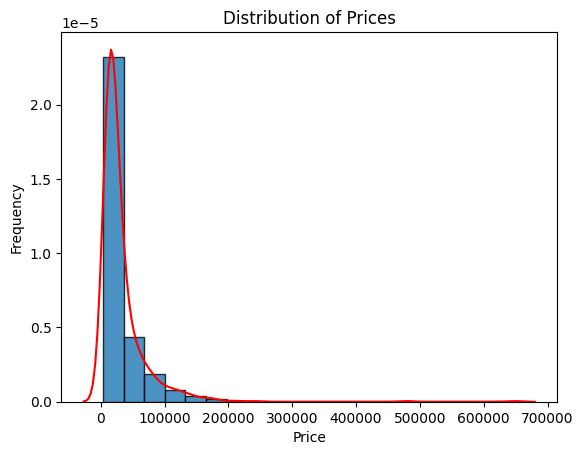

In [5]:
df['price'].plot.hist(bins=20, alpha=0.8, edgecolor='black', density=True)
sns.kdeplot(df['price'], color='red') # KDE

plt.title("Distribution of Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()



In [6]:
df['price'].skew()

np.float64(6.591790999665567)

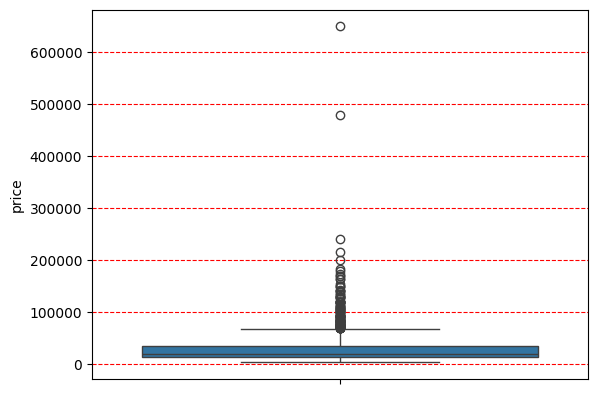

In [7]:
sns.boxplot(df['price'])
plt.grid(True, axis='y', linestyle='--', color='red')

In [8]:
df[df['price'] > 200000]

,brand_name,model,price,rating,sim_type,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,...,fast_charging,display_size_inches,display_resolution,refresh_rate,num_rear_cameras,num_front_cameras,max_rear_camera_MP,max_front_camera_MP,card_supported,os
427,vertu,Vertu Signature Touch,650000,62.0,Single Sim,False,True,False,Snapdragon 801,snapdragon,...,NaN,4.70,1080 x 1920,60,1,1,13.0,2.1,0,Android v4.4.2 (KitKat)
478,huawei,Huawei Mate 50 RS Porsche Design,239999,81.0,Dual Sim,False,True,True,Snapdragon 8+ Gen1,snapdragon,...,66.0,6.74,1212 x 2616,120,3,1,50.0,13.0,1,Hongmeng OS v3.0
887,xiaomi,Xiaomi Redmi K20 Pro Signature Edition,480000,88.0,Dual Sim,False,True,False,Snapdragon 855,snapdragon,...,27.0,6.39,1080 x 2340,60,3,1,48.0,20.0,0,Android v9 (Pie)
951,huawei,Huawei Mate 30 RS Porsche Design,214990,NaN,Dual Sim,True,True,True,Kirin 990,kirin,...,NaN,6.53,1176 x 2400,60,4,2,40.0,32.0,1,Android v10


### Rating

- The rating distribution is slightly skewed to the left, as seen in the histogram and the skewness value.
* The majority of ratings fall between 74 and 84, as indicated by the interquartile range in the descriptive statistics.
* Approximately 10.3% of the rating values are missing.

In [9]:
df['rating'].describe()

,rating
count,879.000000
mean,78.258248
std,7.402854
min,60.000000
25%,74.000000
50%,80.000000
75%,84.000000
max,89.000000


In [14]:
df['rating'].isna().sum()/df.shape[0]*100

np.float64(10.306122448979592)

In [11]:
df['rating'].skew()

np.float64(-0.6989993034105535)

<Axes: xlabel='rating', ylabel='Count'>

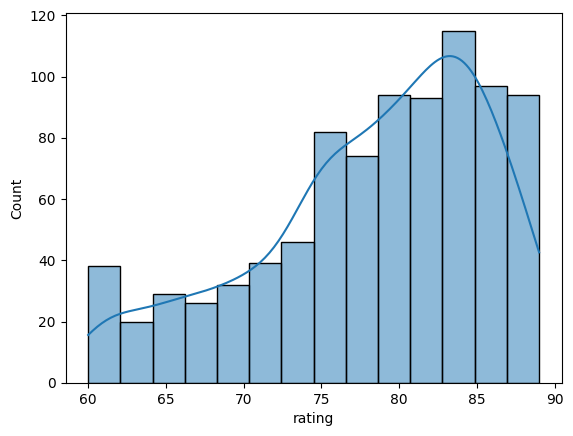

In [12]:
#df['rating'].plot(kind='hist', bins=20, edgecolor='black')
sns.histplot(df['rating'],kde=True)

<Axes: ylabel='rating'>

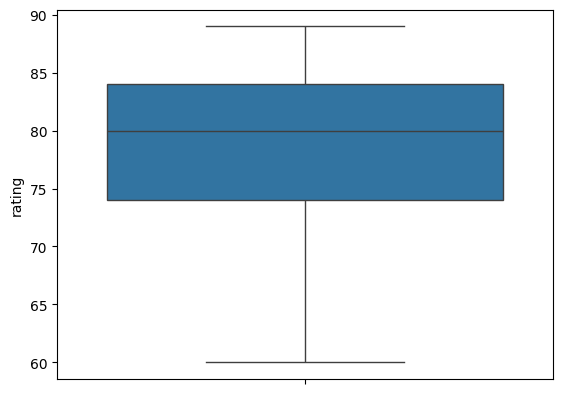

In [13]:
sns.boxplot(df['rating'])

### processor_core

- Most of the phones have Octa-core processors.
- The core distribution is skewed to the left, which is expected since the majority of processors are Octa-core (8 cores), and fewer have lower core counts.
- There are outliers with lower core counts, as shown in the boxplot.
- There are just 0.61% missing values

In [15]:
df['processor_core'].describe()

,processor_core
count,974.000000
mean,7.772074
std,0.836845
min,4.000000
25%,8.000000
50%,8.000000
75%,8.000000
max,8.000000


In [16]:
df['processor_core'].isna().sum()/df.shape[0]*100

np.float64(0.6122448979591837)

In [17]:
df['processor_core'].skew()

np.float64(-3.7580534890844834)

<Axes: xlabel='processor_core', ylabel='Count'>

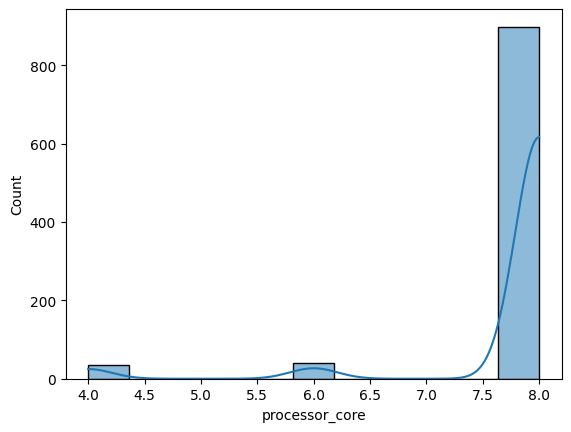

In [18]:
sns.histplot(df['processor_core'],kde=True)

<Axes: ylabel='processor_core'>

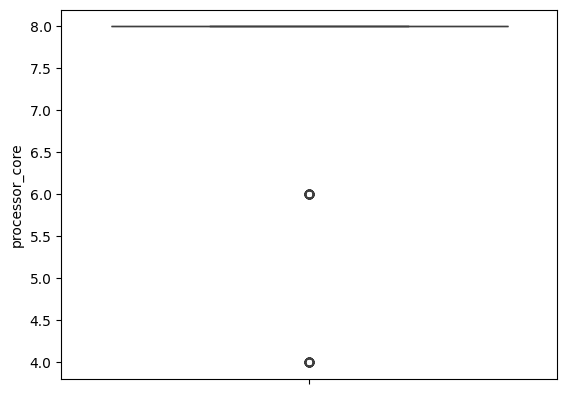

In [19]:
sns.boxplot(df['processor_core'])

### Processor Speed

- The processor speed distribution is nearly symmetrical with a slight positive skew, as indicated by the skewness value close to zero and the histogram.
- The majority of processor speeds are clustered around the mean, with the median speed being very close to the mean.
- There are no significant outliers in processor speed, as seen in the boxplot.
- Approximately 4.2% of the processor speed values are missing.

In [20]:
df['processor_speed'].describe()

,processor_speed
count,938.000000
mean,2.427217
std,0.464090
min,1.200000
25%,2.050000
50%,2.300000
75%,2.840000
max,3.220000


In [21]:
df['processor_speed'].isna().sum()/df.shape[0]*100

np.float64(4.285714285714286)

In [22]:
df['processor_speed'].skew()

np.float64(0.18833557463624606)

<Axes: xlabel='processor_speed', ylabel='Count'>

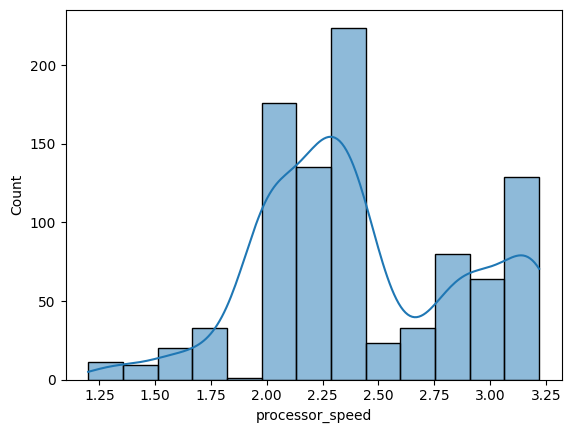

In [23]:
sns.histplot(df['processor_speed'], kde=True)

<Axes: ylabel='processor_speed'>

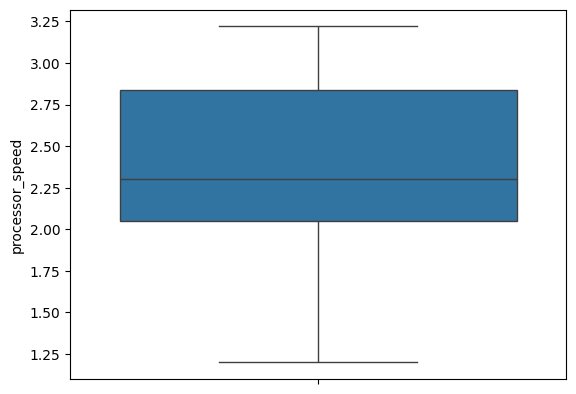

In [24]:
sns.boxplot(df['processor_speed'])

### ram_capacity
- The majority of ram capacity are around the 4 to 8, and the median ram capacity is also close to the mean.
- the ram capacity is highly skewed to the right.
- There are few outliers on the right as seen in the boxplot.


In [32]:
df['ram_capacity'].describe()

,ram_capacity
count,980.000000
mean,6.682653
std,3.774045
min,1.000000
25%,4.000000
50%,6.000000
75%,8.000000
max,64.000000


In [33]:
df['ram_capacity'].isna().sum()/df.shape[0]*100

np.float64(0.0)

In [34]:
df['ram_capacity'].skew()

np.float64(7.406797531322625)

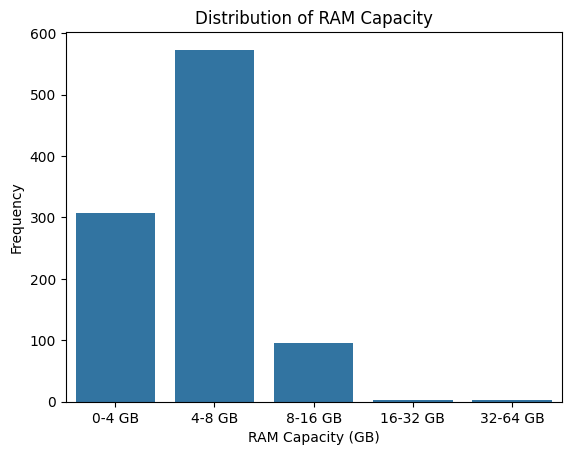

In [35]:
# Example: Bin the 'ram_capacity' column
bins = [0, 4, 8, 16, 32, 64]  # define bin edges (adjust as needed)
labels = ['0-4 GB', '4-8 GB', '8-16 GB', '16-32 GB', '32-64 GB']  # bin labels
temp_ram_bin = pd.cut(df['ram_capacity'], bins=bins, labels=labels, include_lowest=True)

# Count how many fall into each bin
ram_counts = temp_ram_bin.value_counts().sort_index()

# Plot
sns.barplot(x=ram_counts.index, y=ram_counts.values)
plt.xlabel('RAM Capacity (GB)')
plt.ylabel('Frequency')
plt.title('Distribution of RAM Capacity')
plt.show()


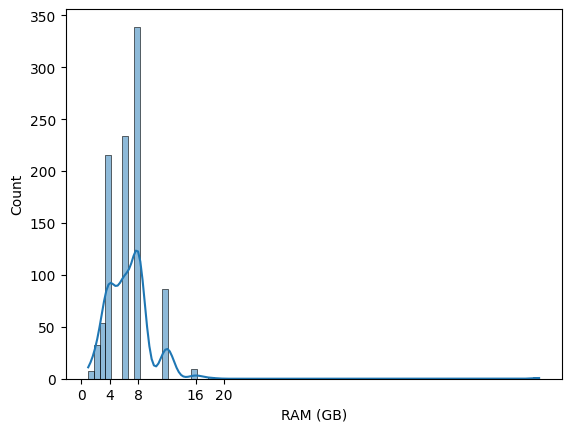

In [36]:
sns.histplot(df['ram_capacity'], kde=True)
plt.xticks([0, 4, 8, 16,20])
plt.xlabel('RAM (GB)')
plt.show()

<Axes: ylabel='ram_capacity'>

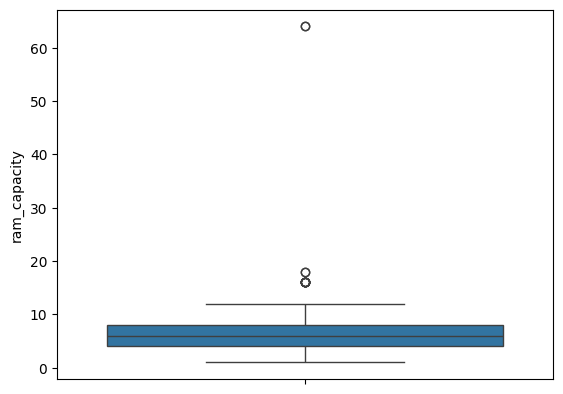

In [37]:
sns.boxplot(df['ram_capacity'])

In [38]:
df[df['ram_capacity'] > 16]

,brand_name,model,price,rating,sim_type,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,...,fast_charging,display_size_inches,display_resolution,refresh_rate,num_rear_cameras,num_front_cameras,max_rear_camera_MP,max_front_camera_MP,card_supported,os
278,asus,Asus ROG Phone 6 Pro 5G,89999,88.0,Dual Sim,True,True,False,Snapdragon 8+ Gen1,snapdragon,...,65.0,6.78,1080 x 2448,165,3,1,50.0,12.0,0,Android v12
406,asus,Asus ROG Phone 7,75990,87.0,Dual Sim,True,True,False,Snapdragon 8 Gen2,snapdragon,...,120.0,6.80,1080 x 2448,165,3,1,64.0,32.0,0,Android v13
435,apple,Apple iPhone SE 3 2022,43900,NaN,Dual Sim,True,True,False,Bionic A15,bionic,...,NaN,4.70,750 x 1334,60,1,1,12.0,7.0,0,iOS v15
737,apple,Apple iPhone SE 4,49990,60.0,Dual Sim,True,True,False,Bionic A15,bionic,...,NaN,6.10,750 x 1580,60,1,1,12.0,10.8,0,iOS v16


### internal_memory

- The distribution of internal memory is highly skewed to the right, with a large number of phones having lower internal memory (64GB and 128GB being the most frequent).
- The mean internal memory is significantly higher than the median due to the presence of larger storage options (256GB, 512GB, and 1024GB).
- There is a small percentage of missing values (around 0.2%).
- There are outliers with higher internal memory, clearly visible in the boxplot.
Overall, the data shows a wide range of internal memory, with a concentration in the lower to mid-range and a few high-memory outliers

In [47]:
df['internal_memory'].describe()

,internal_memory
count,978.000000
mean,141.194274
std,107.187345
min,8.000000
25%,64.000000
50%,128.000000
75%,128.000000
max,1024.000000


In [48]:
df['internal_memory'].isna().sum()/df.shape[0]*100

np.float64(0.20408163265306123)

In [49]:
df['internal_memory'].skew()

np.float64(3.8286562788519363)

In [50]:
df['internal_memory'].quantile([0.01,0.05,0.25,0.5,0.75,0.95,0.99])

,internal_memory
0.01,16.0
0.05,32.0
0.25,64.0
0.50,128.0
0.75,128.0
0.95,256.0
0.99,512.0


In [51]:
df['internal_memory'].value_counts()

,count
internal_memory,
128.0,523
64.0,191
256.0,157
32.0,67
512.0,22
16.0,12
1024.0,5
8.0,1


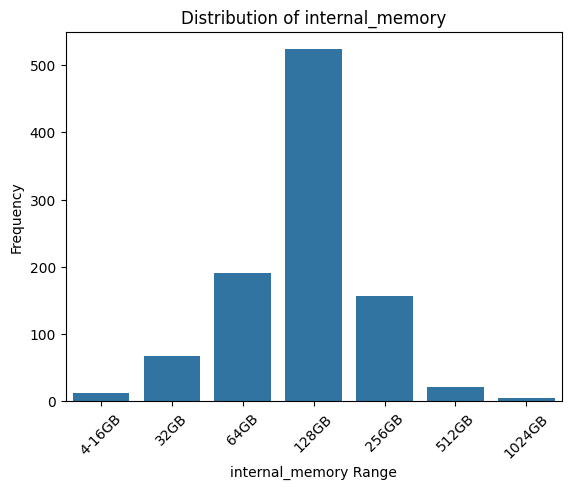

In [52]:
# Define bins and labels (your original ones)
bin = [0, 16, 32, 64, 128, 256, 512, 1024]
label = ['4-16GB', '32GB', '64GB', '128GB', '256GB', '512GB', '1024GB']

# Create a temporary DataFrame for plotting
temp_df = pd.DataFrame()
temp_df['memory_bin'] = pd.cut(df['internal_memory'], bins=bin, labels=label, include_lowest=True)

# Count values per bin
temp_counts = temp_df['memory_bin'].value_counts().sort_index()

# Plot
sns.barplot(x=temp_counts.index, y=temp_counts.values)

plt.xlabel('internal_memory Range')
plt.ylabel('Frequency')
plt.title('Distribution of internal_memory')
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='internal_memory', ylabel='Count'>

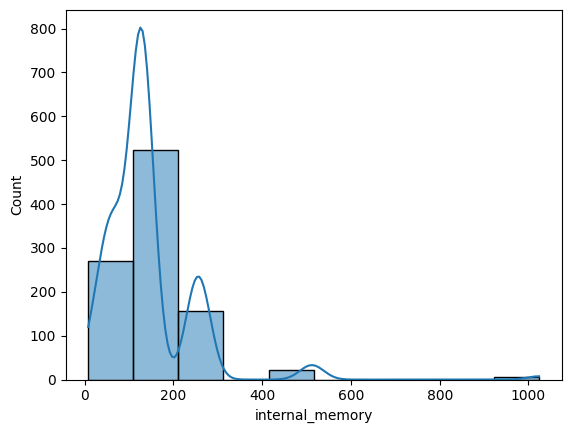

In [53]:
sns.histplot(df['internal_memory'],bins=10,kde=True) # showing rightskew

<Axes: ylabel='internal_memory'>

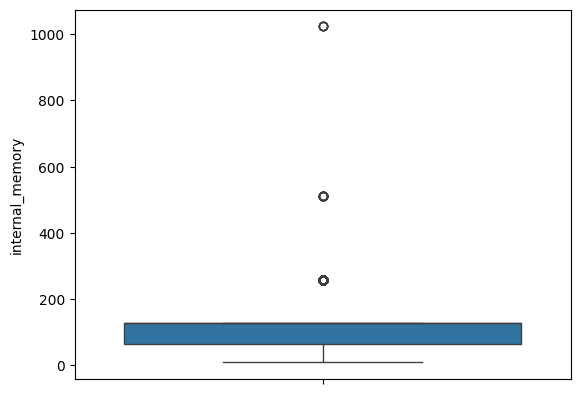

In [54]:
sns.boxplot(df['internal_memory'])

### battery_capacity

- The distribution of battery capacity is heavily skewed to the right, with a large concentration of phones having battery capacities around 5000 mAh, as seen in the histogram.
- The median battery capacity is slightly higher than the mean, likely due to the high concentration of values at 5000 mAh despite the presence of high outliers.
- Approximately 1.12% of the battery capacity values are missing.
- There are several extreme outliers with significantly higher battery capacities, and some lower outliers, which are clearly visible in the boxplot and contribute to the skewness.

In [55]:
df['battery_capacity'].describe()

,battery_capacity
count,969.000000
mean,4817.748194
std,1009.540054
min,1821.000000
25%,4500.000000
50%,5000.000000
75%,5000.000000
max,22000.000000


In [56]:
df['battery_capacity'].isna().sum()/df.shape[0]*100

np.float64(1.1224489795918366)

In [57]:
df['battery_capacity'].skew()

np.float64(9.260986328291182)

In [58]:
df['battery_capacity'].quantile([0.01,0.05,0.2,0.5,0.75,0.99])

,battery_capacity
0.01,2656.4
0.05,3500.0
0.20,4450.0
0.50,5000.0
0.75,5000.0
0.99,6320.0


<Axes: xlabel='battery_capacity', ylabel='Count'>

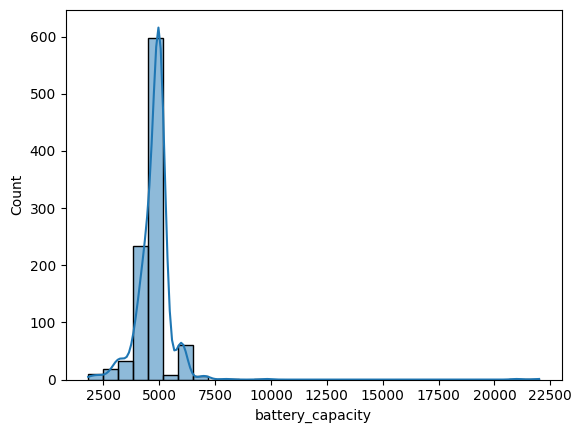

In [59]:
sns.histplot(df['battery_capacity'],bins=30,kde=True) # showing rightskew

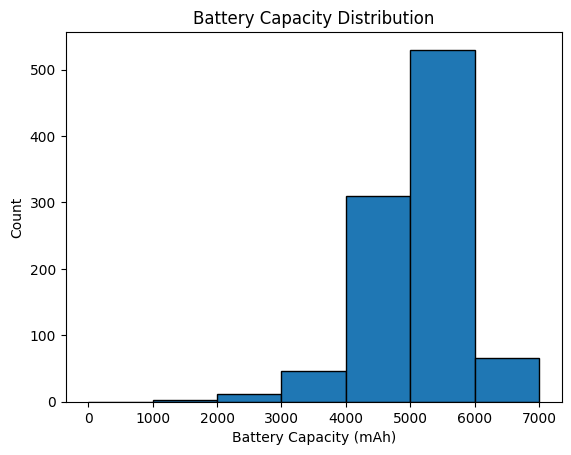

In [60]:
bins = [0, 1000, 2000, 3000, 4000, 5000,6000,7000]  # we have trimmed the bin that why looking highs on right

df['battery_capacity'].plot(kind='hist', bins=bins, edgecolor='black')

plt.xlabel('Battery Capacity (mAh)')
plt.ylabel('Count')
plt.title('Battery Capacity Distribution')
plt.show()

<Axes: ylabel='battery_capacity'>

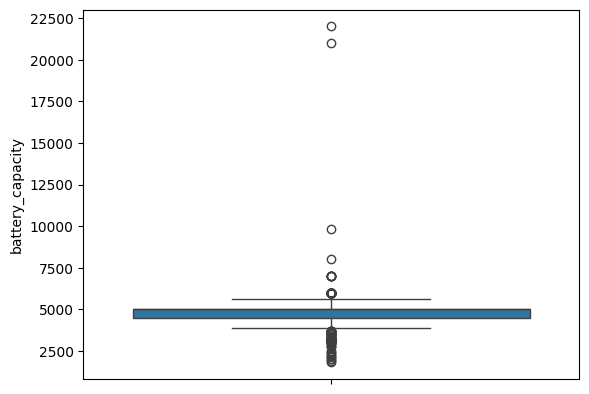

In [61]:
sns.boxplot(df['battery_capacity'])

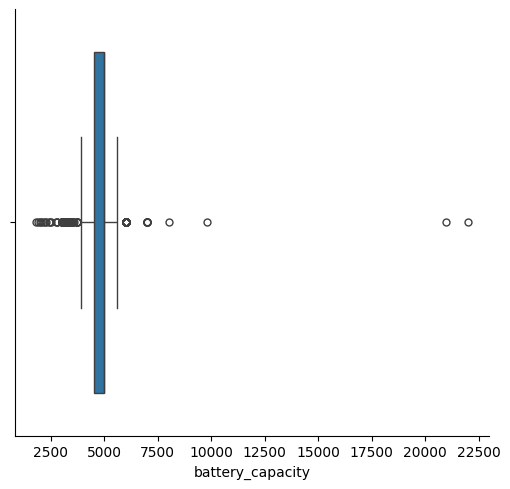

In [62]:
sns.catplot(kind = 'box',data = df, x = 'battery_capacity')

### fast_charging

- Central Tendency: Mean=46.12W, Median=33W - indicating right-skewed distribution
- Missing Data: 21.53% missing values (phones without fast charging or unavailable data)
- Distribution: Highly right-skewed (skewness=1.65) - most phones have lower charging speeds
- Range: 10W to 240W; 75% of phones 66W; only 1% exceed 150W
- Market Concentration: Majority in 0-50W range (mid-range segment dominance)
- Consumer Insight: Fast charging varies by price point - budget phones (15-33W), flagships (100W+)

In [69]:
df['fast_charging'].describe()

,fast_charging
count,769.000000
mean,46.129649
std,34.275769
min,10.000000
25%,18.000000
50%,33.000000
75%,66.000000
max,240.000000


In [70]:
df['fast_charging'].isna().sum()/df.shape[0]*100

np.float64(21.53061224489796)

In [71]:
df['fast_charging'].skew()

np.float64(1.6457130828680924)

In [72]:
df['fast_charging'].quantile([0.01,0.05,0.2,0.5,0.75,0.99])

,fast_charging
0.01,10.0
0.05,15.0
0.20,18.0
0.50,33.0
0.75,66.0
0.99,150.0


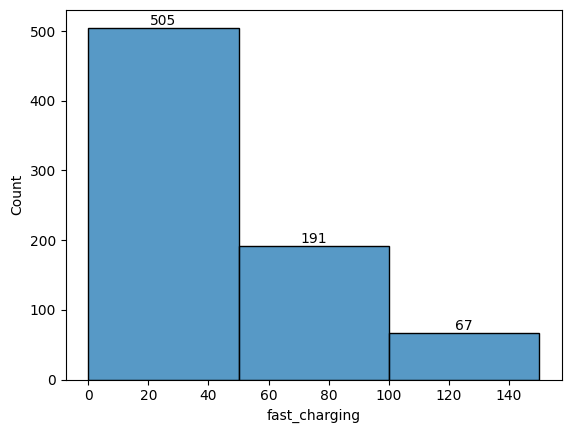

In [73]:
ax = sns.histplot(df['fast_charging'], bins=[0,50,100,150],
                  edgecolor='black', stat='count')

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d')  # integer count labels

plt.show()


<Axes: ylabel='fast_charging'>

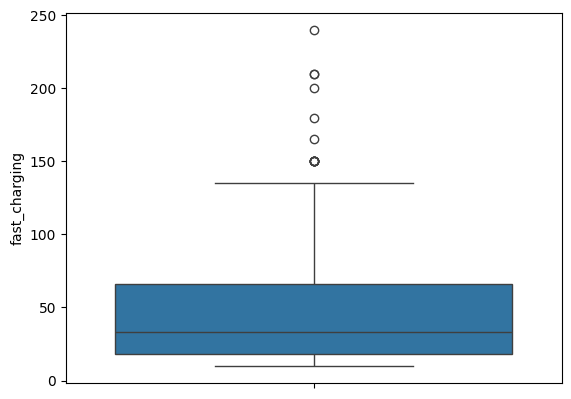

In [74]:
sns.boxplot(df['fast_charging'])

### display_size_inches

- Mean and Median are closely related.
- There is no missing value.
- The distribution of display_size is highly skewed at left.
- There are several outliers with significantly smaller display sizes, which are clearly visible as individual points below the lower whisker of the boxplot. These represent phones with much smaller screens compared to the majority of the dataset.

In [75]:
df['display_size_inches'].describe()

,display_size_inches
count,980.000000
mean,6.536765
std,0.349162
min,3.540000
25%,6.500000
50%,6.580000
75%,6.670000
max,8.030000


In [76]:
df['display_size_inches'].isna().sum()

np.int64(0)

In [77]:
df['display_size_inches'].skew()

np.float64(-2.11619902968816)

In [78]:
df['display_size_inches'].quantile([0.01,0.05,0.1,0.5,0.75,0.99])

,display_size_inches
0.01,5.000
0.05,6.100
0.10,6.300
0.50,6.580
0.75,6.670
0.99,7.642


<Axes: ylabel='Frequency'>

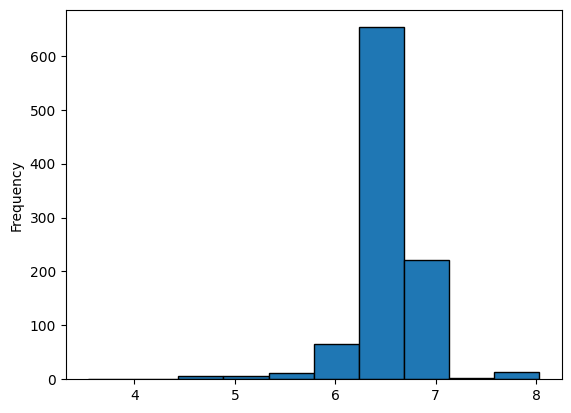

In [79]:
df['display_size_inches'].plot(kind = 'hist',edgecolor = 'black')

<Axes: ylabel='display_size_inches'>

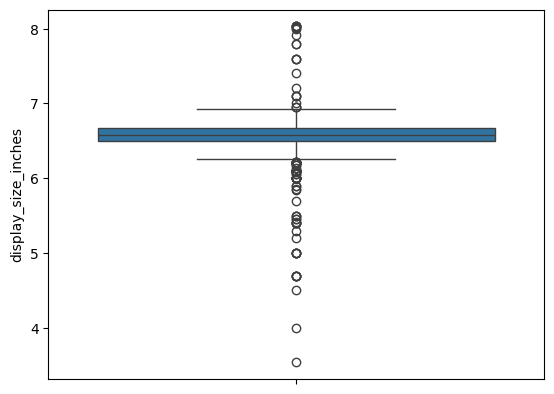

In [80]:
sns.boxplot(df['display_size_inches'])

### refresh_rate

- The mean and mean are closely related.
- There are no missing values.
- Many phones have refresh rate of 60 Hz or 120 Hz.
- There exist only one phone with 240 Hz (outlier).

In [89]:
df['refresh_rate'].describe()

,refresh_rate
count,980.000000
mean,92.256122
std,28.988052
min,60.000000
25%,60.000000
50%,90.000000
75%,120.000000
max,240.000000


In [90]:
df['refresh_rate'].isna().sum()

np.int64(0)

In [91]:
df['refresh_rate'].skew()

np.float64(0.29773297483356714)

In [92]:
df['refresh_rate'].quantile([0,0.05,0.25,0.5,0.75,0.99])

,refresh_rate
0.00,60.00
0.05,60.00
0.25,60.00
0.50,90.00
0.75,120.00
0.99,148.41


In [93]:
df['refresh_rate'].value_counts()

,count
refresh_rate,
60,368
120,344
90,219
144,39
165,9
240,1


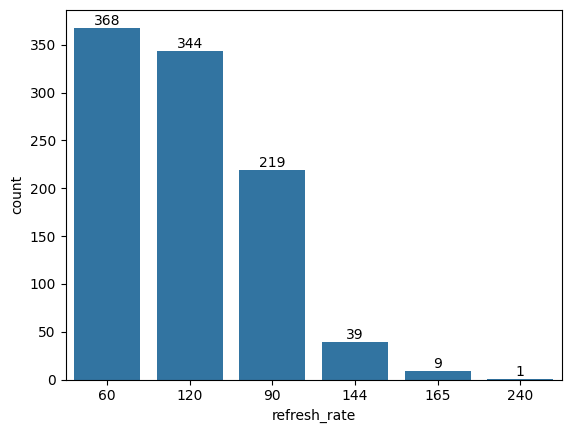

In [94]:
counts = df['refresh_rate'].value_counts().reset_index()
counts.columns = ['refresh_rate', 'count']

# Plot, ordered by count descending
ax = sns.barplot(data=counts, x='refresh_rate', y='count', order=counts['refresh_rate'])

for container in ax.containers:
  ax.bar_label(container=container)

plt.show()

<Axes: ylabel='refresh_rate'>

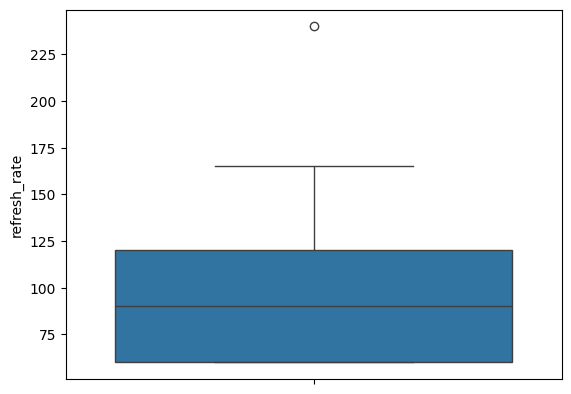

In [95]:
sns.boxplot(df['refresh_rate'])

In [96]:
df[df['refresh_rate']>175]

,brand_name,model,price,rating,sim_type,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,...,fast_charging,display_size_inches,display_resolution,refresh_rate,num_rear_cameras,num_front_cameras,max_rear_camera_MP,max_front_camera_MP,card_supported,os
784,leitz,Leitz Phone 2,124990,89.0,Dual Sim,True,True,False,Snapdragon 8 Gen1,snapdragon,...,NaN,6.6,1260 x 2730,240,2,1,47.2,12.6,1,Android v12


### num_rear_cameras
- Most number of phones have 3 rear camera's.
- The distribution of rear cameras is slightly left skewed.
- There are no outliers.

In [97]:
df['num_rear_cameras'].describe()

,num_rear_cameras
count,980.000000
mean,2.814286
std,0.776441
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,4.000000


In [98]:
df['num_rear_cameras'].isna().sum()

np.int64(0)

In [99]:
df['num_rear_cameras'].skew()

np.float64(-0.518011715428992)

<Axes: xlabel='num_rear_cameras'>

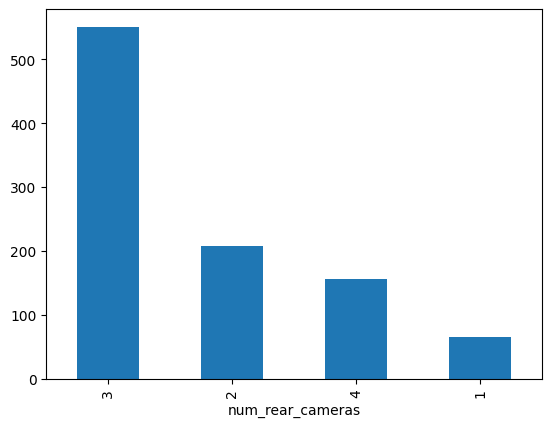

In [107]:
df['num_rear_cameras'].value_counts().plot(kind = 'bar')

<Axes: xlabel='num_rear_cameras', ylabel='Count'>

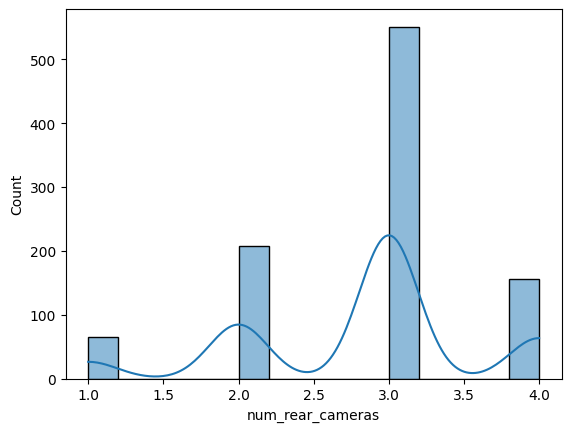

In [108]:
sns.histplot(df['num_rear_cameras'],kde=True)

<Axes: ylabel='num_front_cameras'>

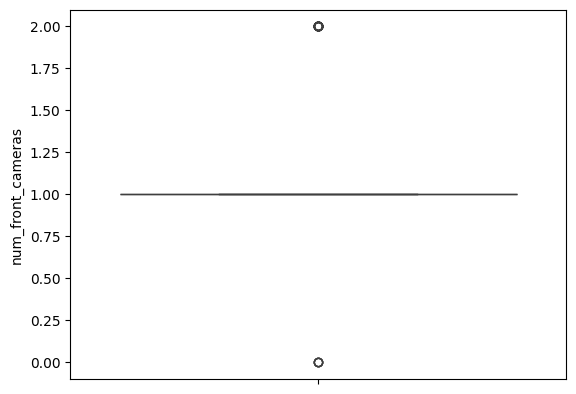

In [101]:
sns.boxplot(df['num_front_cameras'])

### num_front_cameras

- Most phones have only one front camera.
- A small number of phones have two front cameras.
There are a few phones with zero front cameras (likely older or feature phones).
- The distribution is heavily skewed to the right due to the large number of phones with a single front camera.
- There are outliers with zero or two front cameras, as shown in the boxplot and value counts.
- There are no missing values in this column.

In [109]:
df['num_front_cameras'].describe()

,num_front_cameras
count,980.000000
mean,1.025510
std,0.181814
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,2.000000


In [110]:
df['num_front_cameras'].isna().sum()

np.int64(0)

In [115]:
df['num_front_cameras'].skew()

np.float64(3.832999513862698)

<Axes: xlabel='num_front_cameras'>

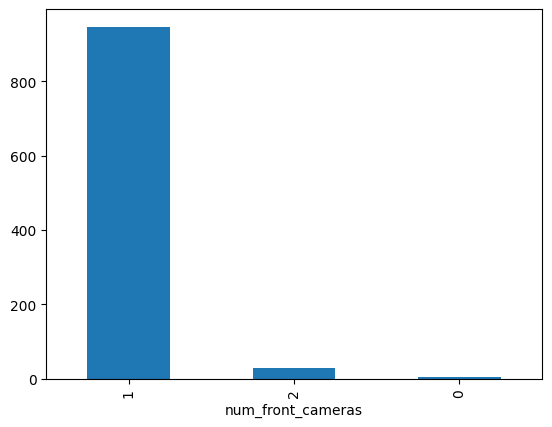

In [117]:
df['num_front_cameras'].value_counts().plot(kind = 'bar')

<Axes: >

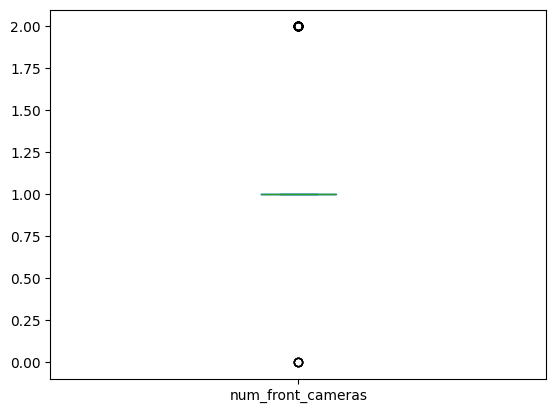

In [113]:
df['num_front_cameras'].plot(kind='box')

### max_rear_camera_MP

- The mean and median is almost same.
- There are no missing values.
- The distribution of max MP is skewed at right.
- Most of the phone has max MP between 40 to 55 MP.
- There are 18 phones having 200 MP rear camera.

In [118]:
def analysis(x):
    print(" Summary Statistics:\n", x.describe(), "\n")

    # Missing values
    print(" Missing Values:\n", x.isna().sum(), "\n")

    # Print missing percentage only if NaN values exist
    if x.isna().sum() > 0:
        missing_pct = x.isna().sum() / x.shape[0] * 100
        print(f" Missing Percentage: {missing_pct:.2f}%\n")

    # Skewness
    print(" Skewness:\n", x.skew(), "\n")

    # Histogram
    x.plot(kind='hist', title=f'Histogram of {x.name}', edgecolor='black')
    plt.xlabel(x.name)
    plt.ylabel('Frequency')
    plt.show()

    # Boxplot
    x.plot(kind='box', title=f'Boxplot of {x.name}')
    plt.show()


 Summary Statistics:
 count    980.000000
mean      50.319286
std       33.000968
min        2.000000
25%       24.000000
50%       50.000000
75%       64.000000
max      200.000000
Name: max_rear_camera_MP, dtype: float64 

 Missing Values:
 0 

 Skewness:
 1.7705785615913048 



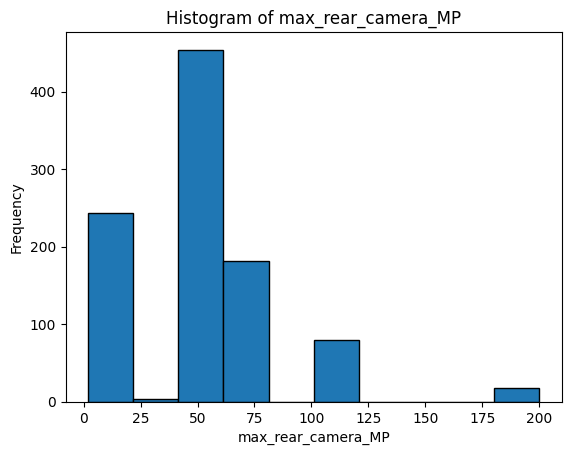

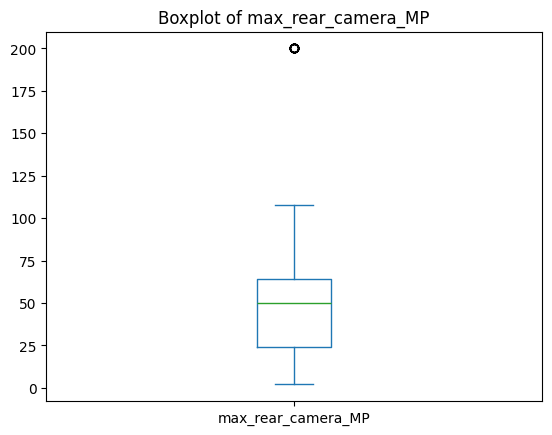

In [119]:
analysis(df['max_rear_camera_MP'])

In [120]:
(df['max_rear_camera_MP'] == 200).sum()

np.int64(18)

### max_front_camera_MP
- Mean and median are closely related.
- There are 0.41% missing values.
- The distribution is skewed to the right
- Many front camera MP lies between 8 to 18.
- There are many outliers present in the right as seen in the boxplot.

 Summary Statistics:
 count    976.000000
mean      16.588525
std       10.871239
min        0.300000
25%        8.000000
50%       16.000000
75%       16.000000
max       60.000000
Name: max_front_camera_MP, dtype: float64 

 Missing Values:
 4 

 Missing Percentage: 0.41%

 Skewness:
 1.4406027157852361 



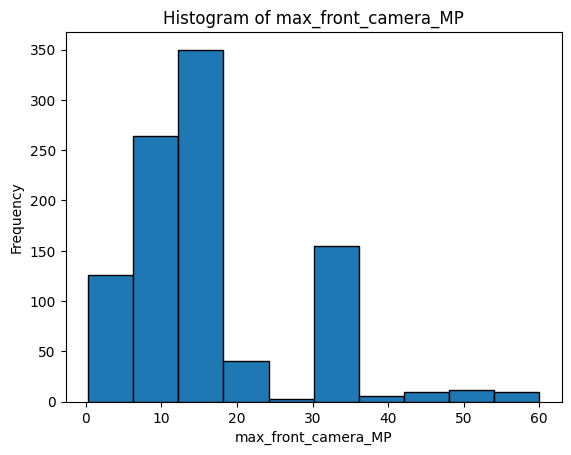

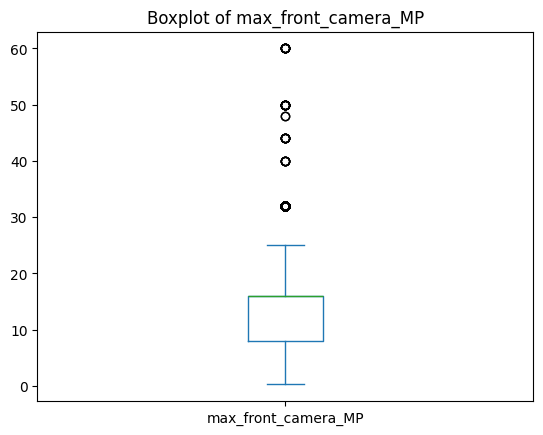

In [121]:
analysis(df['max_front_camera_MP'])

### card_supported

In [125]:
df['card_supported'].describe()

,card_supported
count,980.000000
mean,0.630612
std,0.482885
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [126]:
df['card_supported'].value_counts(normalize=True) * 100

,proportion
card_supported,
1,63.061224
0,36.938776


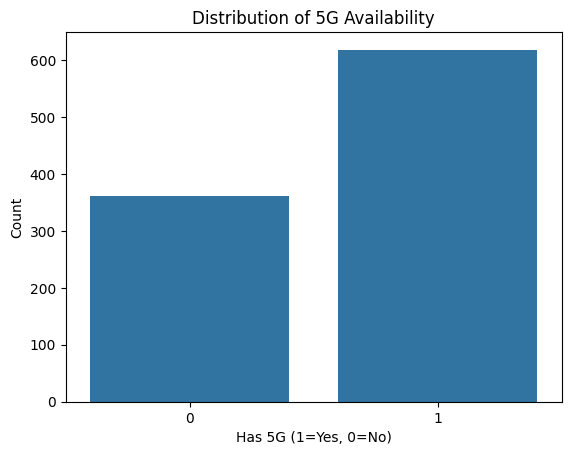

In [127]:
sns.countplot(x=df['card_supported'])
plt.title('Distribution of 5G Availability')
plt.xlabel('Has 5G (1=Yes, 0=No)')
plt.ylabel('Count')
plt.show()

## **Categorical Columns**

### brand_name

- There are a total of 46 unique smartphone brands in the dataset.
- Xiaomi, Samsung, and Vivo are the most represented brands, having the highest frequency of models in the dataset.
- The distribution of models across brands is uneven, with a few major players dominating the market share in this dataset.
- There are no missing values in the brand_name column.

In [128]:
df['brand_name'].describe()

,brand_name
count,980
unique,46
top,xiaomi
freq,134


In [129]:
df['brand_name'].value_counts()

,count
brand_name,
xiaomi,134
samsung,132
vivo,111
realme,97
oppo,88
motorola,52
apple,46
oneplus,42
poco,41


In [130]:
df['brand_name'].isna().sum()

np.int64(0)

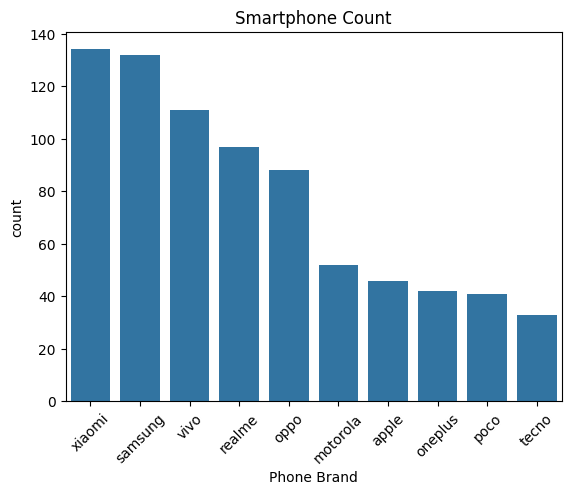

In [131]:
sns.barplot(df['brand_name'].value_counts().head(10))
plt.xticks(rotation=45)
plt.title("Smartphone Count")
plt.xlabel("Phone Brand")
plt.show()

### model

- There are 980 unique smartphone models in the dataset, which is equal to the number of rows after cleaning.
- This indicates that each row represents a distinct smartphone model.
- There are no missing values in the model column.

In [132]:
df['model'].describe()

,model
count,980
unique,980
top,Samsung Galaxy M52s 5G
freq,1


In [133]:
df['model'].isna().sum()

np.int64(0)

### sim_type

- The vast majority of smartphones in the dataset (98.4%) are Dual Sim phones.
- Only a small percentage (1.4%) are Single Sim phones.
- There are no missing values in this column.

In [134]:
df['sim_type'].describe()

,sim_type
count,980
unique,2
top,Dual Sim
freq,964


In [135]:
df['sim_type'].value_counts()

,count
sim_type,
Dual Sim,964
Single Sim,16


<Axes: ylabel='count'>

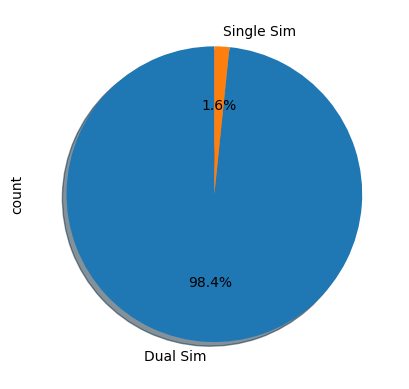

In [136]:
df['sim_type'].value_counts().plot(kind='pie',autopct='%1.1f%%',startangle=90,shadow=True)

### has_5g

- More than half of the smartphones in the dataset (56.2%) have 5G capability.
- A significant portion (43.98%) do not have 5G capability.
There are no missing values in this column.



In [137]:
df['has_5g'].describe()

,has_5g
count,980
unique,2
top,True
freq,549


In [138]:
df['has_5g'].value_counts()

,count
has_5g,
True,549
False,431


In [139]:
df['has_5g'].isna().sum()

np.int64(0)

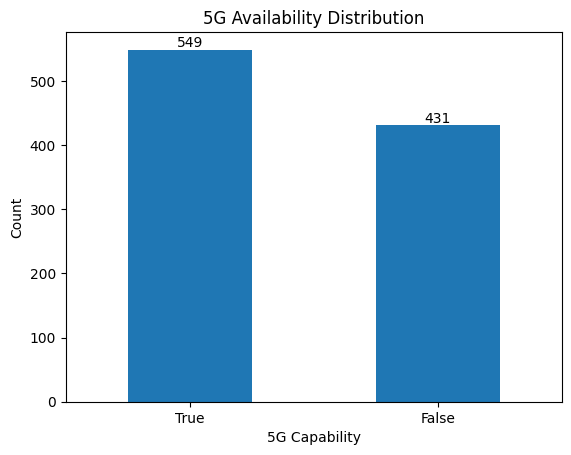

In [140]:
ax = df['has_5g'].value_counts().plot(kind='bar')
plt.xticks(rotation=0)
plt.title("5G Availability Distribution")
plt.xlabel('5G Capability')
plt.ylabel('Count')

ax.bar_label(ax.containers[0])

plt.show()

<Axes: ylabel='count'>

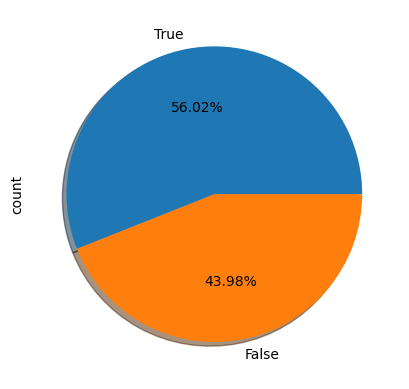

In [141]:
df['has_5g'].value_counts().plot(kind='pie',autopct='%0.2f%%',shadow = True)

### has_nfc

- 40% phones have NFCs
- There is no missing value


In [142]:
df['has_nfc'].describe()

,has_nfc
count,980
unique,2
top,False
freq,587


In [143]:
df['has_nfc'].isna().sum()

np.int64(0)

In [144]:
df['has_nfc'].value_counts()

,count
has_nfc,
False,587
True,393


<Axes: ylabel='count'>

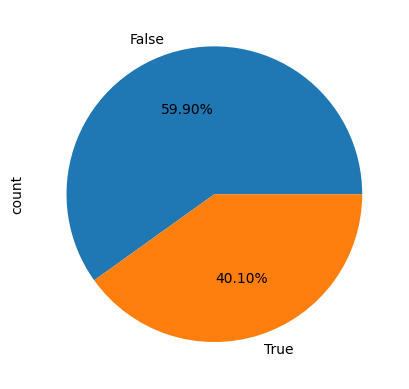

In [145]:
df['has_nfc'].value_counts().plot(kind = 'pie',autopct = '%0.2f%%')

### has_ir_blaster

In [151]:
df['has_ir_blaster'].describe()

,has_ir_blaster
count,980
unique,2
top,False
freq,821


In [152]:
df['has_ir_blaster'].isna().sum()

np.int64(0)

In [153]:
df['has_ir_blaster'].value_counts()

,count
has_ir_blaster,
False,821
True,159


<Axes: ylabel='count'>

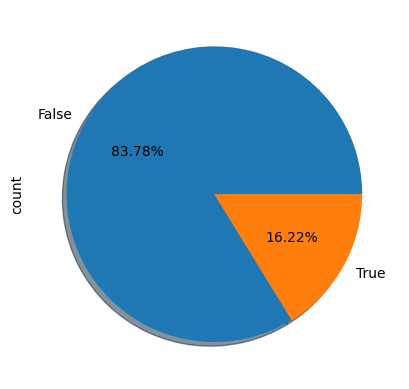

In [154]:
df['has_ir_blaster'].value_counts().plot(kind = 'pie',autopct = '%0.2f%%',shadow = True)

In [155]:
df[df['has_ir_blaster']==True]['brand_name'].value_counts()

,count
brand_name,
xiaomi,109
poco,30
iqoo,6
huawei,6
vivo,4
redmi,2
honor,1
samsung,1


### display_resolution

- There are 83 unique resolutions in the dataset.
- The most common resolution is 1080x2400.
- The top 10 resolutions account for a significant portion of the dataset. It covers 78.98% of all devices

In [162]:
df['display_resolution'].describe()

,display_resolution
count,980
unique,83
top,1080 x 2400
freq,342


In [163]:
df['display_resolution'].nunique()

83

In [164]:
df['display_resolution'].isna().sum()

np.int64(0)

In [165]:
df['display_resolution'].value_counts().head(10)

,count
display_resolution,
1080 x 2400,342
720 x 1600,149
1080 x 2408,65
1080 x 2412,58
1080 x 2340,43
1080 x 2460,39
1440 x 3200,31
720 x 1612,18
1170 x 2532,16


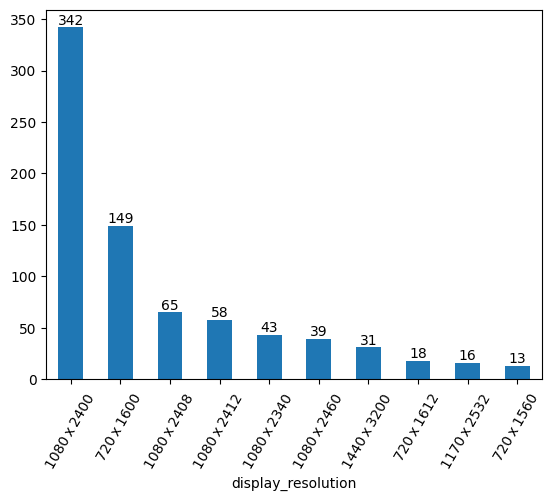

In [166]:
ax = df['display_resolution'].value_counts().head(10).plot(kind = 'bar')
plt.bar_label(ax.containers[0])
plt.xticks(rotation = 60)
plt.show()

<Axes: ylabel='count'>

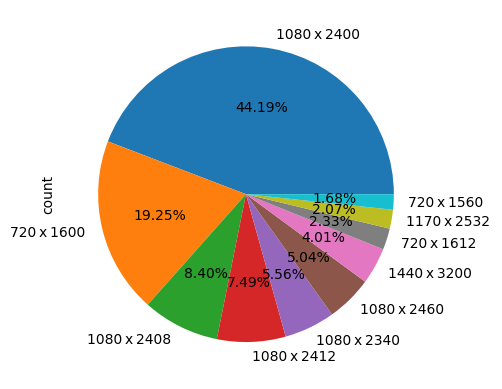

In [167]:
df['display_resolution'].value_counts().head(10).plot(kind = 'pie',autopct = '%0.2f%%')

In [173]:
top10_share = df['display_resolution'].value_counts(normalize=True).head(10).sum() * 100
print(f"Top 10 resolutions cover {top10_share:.2f}% of all devices.")

Top 10 resolutions cover 78.98% of all devices.


### os

- There are 27 unique operating systems in the dataset.
- Android is the most prevalent operating system, with various versions like v12, v11, and v10 being the most common.
- iOS is the second most common operating system.
- There are a small number of missing values (14).

In [157]:
df['os'].describe()

,os
count,966
unique,27
top,Android v12
freq,394


In [158]:
df['os'].isna().sum()

np.int64(14)

In [159]:
df['os'].value_counts().head(10)

,count
os,
Android v12,394
Android v11,278
Android v10,92
Android v13,91
Android v9 (Pie),30
iOS v16,15
iOS v15,15
Android v8.1 (Oreo),10
iOS v14,8


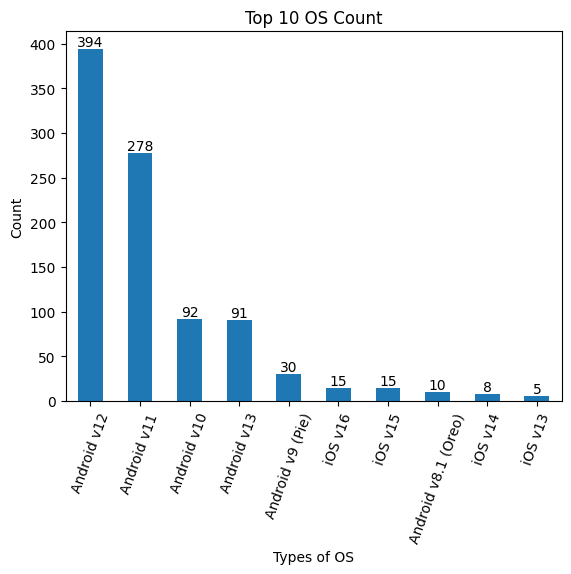

In [160]:

ax = df['os'].value_counts().head(10).plot(kind = 'bar')
plt.bar_label(ax.containers[0])
plt.xticks(rotation = 70)
plt.xlabel("Types of OS")
plt.ylabel("Count")
plt.title("Top 10 OS Count")
plt.show()

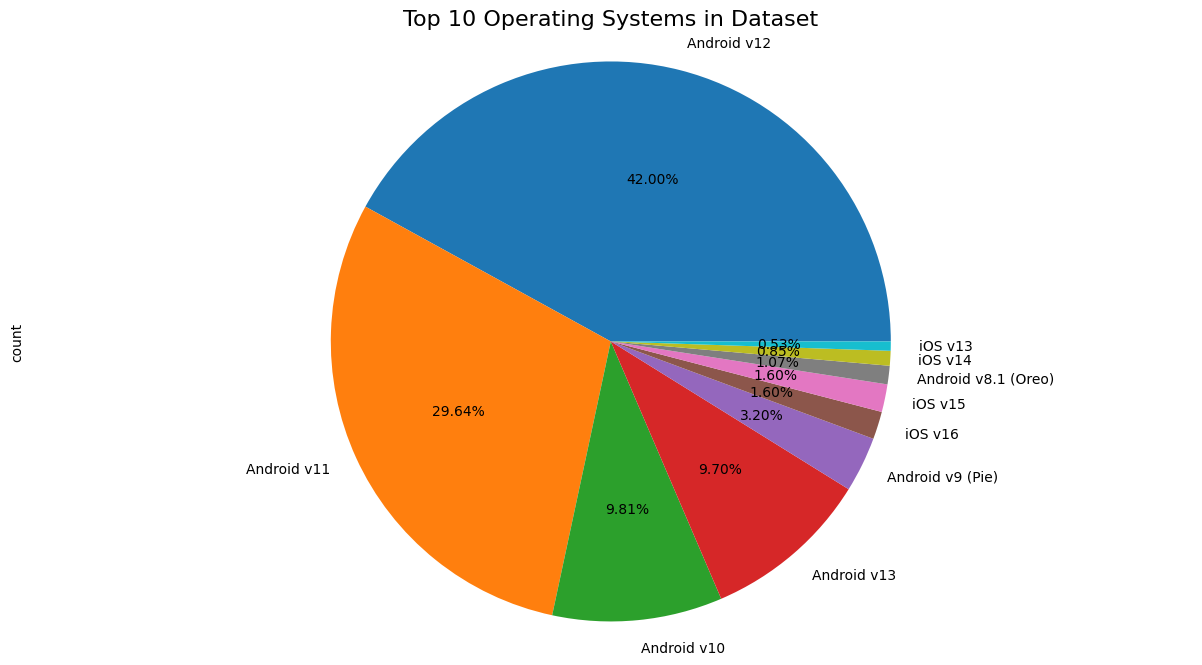

In [161]:
plt.figure(figsize=(15,8))
df['os'].value_counts().head(10).plot(kind = 'pie',autopct = '%0.2f%%')
plt.title("Top 10 Operating Systems in Dataset", fontsize=16)
plt.axis('equal')
plt.show()

## **Bivariate Analysis**

### price vs rating

- There is no strong positive correlation between price and user ratings.

- Both high-priced and low-priced smartphones can achieve high ratings.

- This suggests that factors other than price (possibly features, reliability, or brand value) play a significant role in customer satisfaction.

- Spending more does not guarantee a higher-rated device.

In [178]:
df.head()

,brand_name,model,price,rating,sim_type,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,...,fast_charging,display_size_inches,display_resolution,refresh_rate,num_rear_cameras,num_front_cameras,max_rear_camera_MP,max_front_camera_MP,card_supported,os
0,oneplus,OnePlus 11 5G,54999,89.0,Dual Sim,True,True,False,Snapdragon 8 Gen2,snapdragon,...,100.0,6.70,1440 x 3216,120,3,1,50.0,16.0,0,Android v13
1,oneplus,OnePlus Nord CE 2 Lite 5G,19989,81.0,Dual Sim,True,False,False,Snapdragon 695,snapdragon,...,33.0,6.59,1080 x 2412,120,3,1,64.0,16.0,1,Android v12
2,samsung,Samsung Galaxy A14 5G,16499,75.0,Dual Sim,True,False,False,Exynos 1330,exynos,...,15.0,6.60,1080 x 2408,90,3,1,50.0,13.0,1,Android v13
3,motorola,Motorola Moto G62 5G,14999,81.0,Dual Sim,True,False,False,Snapdragon 695,snapdragon,...,NaN,6.55,1080 x 2400,120,3,1,50.0,16.0,1,Android v12
4,realme,Realme 10 Pro Plus,24999,82.0,Dual Sim,True,False,False,Dimensity 1080,dimensity,...,67.0,6.70,1080 x 2412,120,3,1,108.0,16.0,0,Android v13


<Axes: xlabel='rating', ylabel='price'>

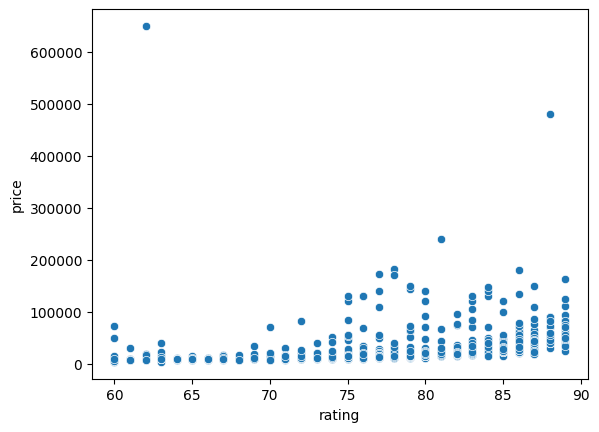

In [179]:
sns.scatterplot(data=df, x = 'rating', y= 'price')

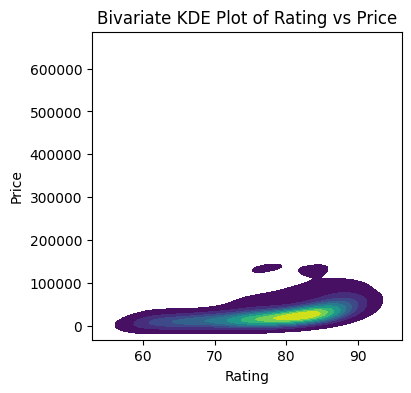

In [180]:
plt.figure(figsize=(4,4))
sns.kdeplot(
    x=df['rating'],
    y=df['price'],
    fill=True, # for shaded visualization
    cmap='viridis'
)
plt.xlabel('Rating')
plt.ylabel('Price')
plt.title('Bivariate KDE Plot of Rating vs Price')
plt.show()

### price vs brand_name

/tmp/ipython-input-1732519732.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


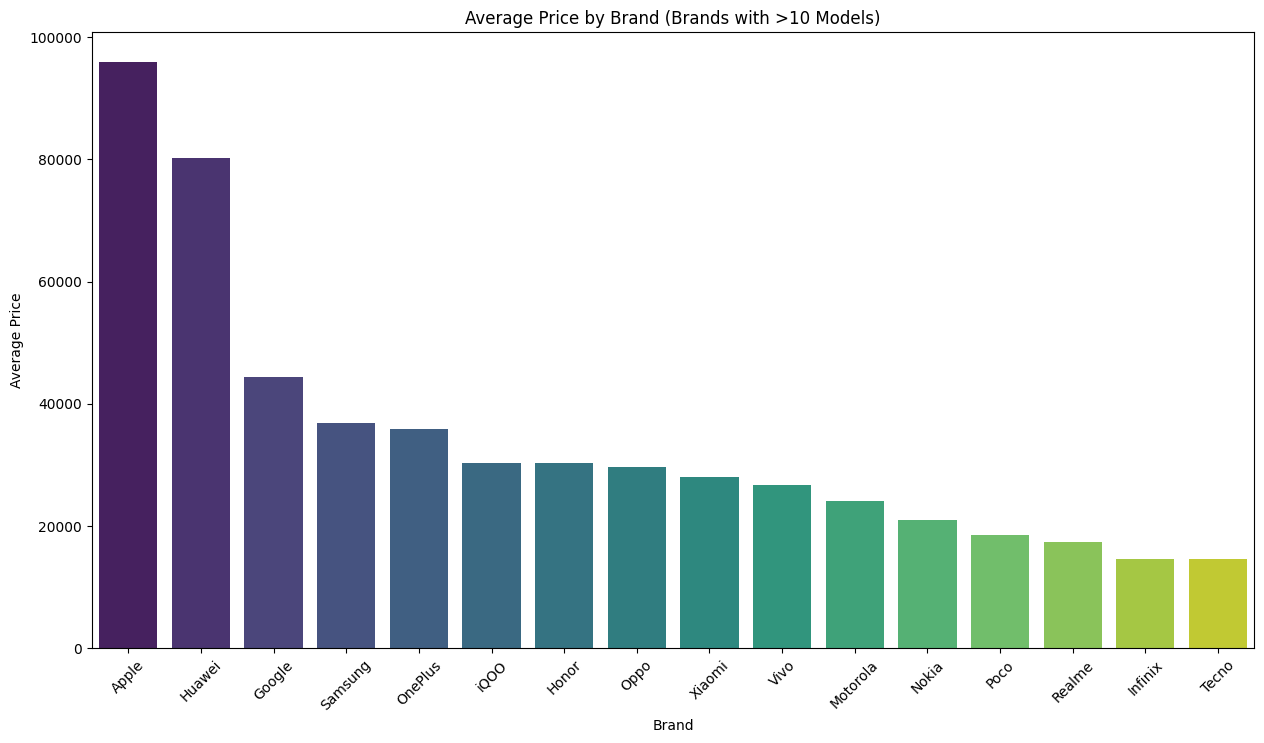

In [ ]:
# Step 1: Get brand counts
brand_counts = df['brand_name'].value_counts()

# Step 2: Get brands with more than 10 models
big_brands = brand_counts[brand_counts > 10].index

# Step 3: Subset dataframe to these brands
df_bigbrands = df[df['brand_name'].isin(big_brands)]

# Step 4: Group and get mean price
mean_price = (
    df_bigbrands.groupby('brand_name')['price']
    .mean()
    .sort_values(ascending=False)
)

# Step 5: Plot
plt.figure(figsize=(15,8))
sns.barplot(
    x=mean_price.index,
    y=mean_price.values,
    palette='viridis'
)
plt.title("Average Price by Brand (Brands with >10 Models)")
plt.xticks(rotation=45)
plt.ylabel("Average Price")
plt.xlabel("Brand")
plt.show()


### price VS sim_type

- The smartphone market is dominated by Dual SIM phones, which are accessible at nearly every price point.

- Single SIM devices, though less common, have higher average prices and greater spread, mostly due to a few premium models.

- Dual SIM phones are more affordable generally, but both categories have high-end outliers.

- The large price range and presence of expensive outliers signal segmentation within both SIM types, but especially notable in the Single SIM group.

- This distribution supports the observation that Dual SIM is a mainstream feature, while Single SIM may remain in specific high-end, specialized, or legacy lines.

In [181]:
df.groupby('sim_type')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
sim_type,,,,,,,,
Dual Sim,964.0,31610.146266,34206.750762,3499.0,12999.00,19990.0,34999.0,480000.0
Single Sim,16.0,87369.562500,153667.283350,14999.0,26492.25,43994.5,72990.0,650000.0


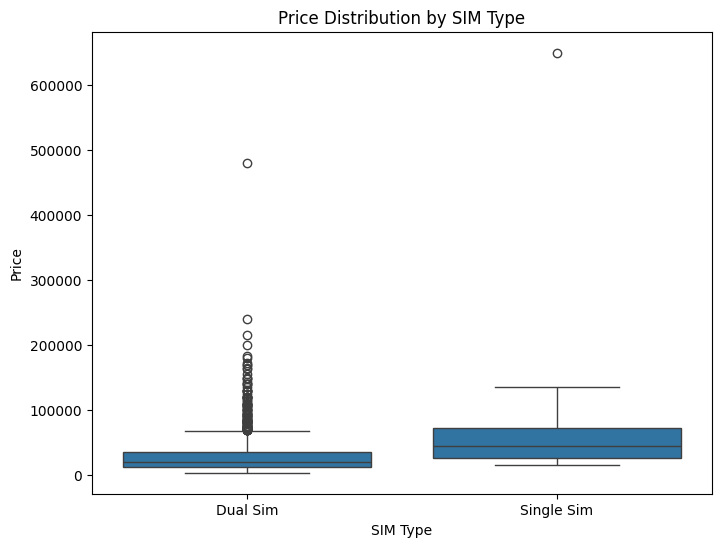

In [182]:
plt.figure(figsize=(8,6))
sns.boxplot(x='sim_type', y='price', data=df)
plt.title("Price Distribution by SIM Type")
plt.  xlabel("SIM Type")
plt.ylabel("Price")
plt.show()


/tmp/ipython-input-458953306.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sim_type', y='price', data=df, estimator=np.median, palette='viridis')


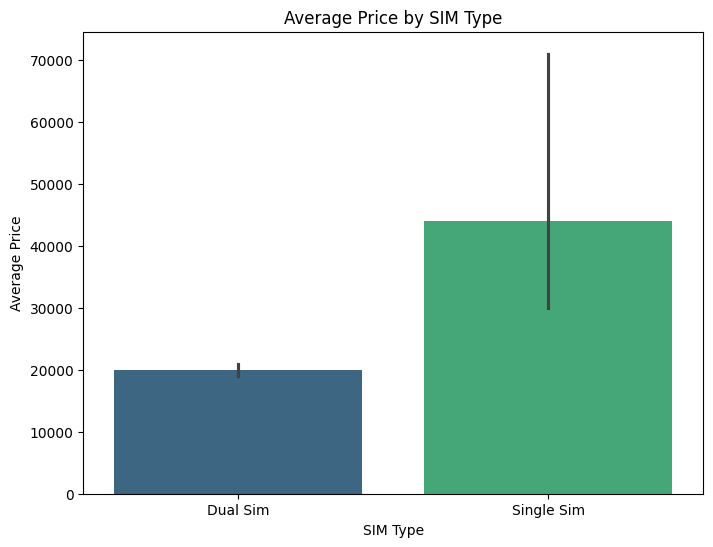

In [183]:
plt.figure(figsize=(8,6))
sns.barplot(x='sim_type', y='price', data=df, estimator=np.median, palette='viridis')
plt.title("Average Price by SIM Type")
plt.xlabel("SIM Type")
plt.ylabel("Average Price")
plt.show()


### price vs has_5g

- Smartphones with 5G support have a much higher median price than those without 5G.

- The distribution plots (boxplots) show that 5G devices not only have higher central values but also a broader price range, including more expensive models.

- Non-5G phones generally cluster at lower prices but have a few extreme outliers.

- The addition of 5G drives up the cost, indicating that 5G is mostly present in recent, premium, or upper-midrange smartphones.

- Presence of several outliers in both categories signals the existence of luxury or specialized devices, but the overall pricing trend is clear.


In [ ]:
df.groupby('has_5g')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
has_5g,,,,,,,,
False,433.0,18830.265589,41909.544985,3499.0,8999.0,12499.0,16499.0,650000.0
True,548.0,43225.781022,33914.478605,8990.0,20499.0,29999.0,54067.5,214990.0


Text(0.5, 1.0, 'Price Distribution based on Network')

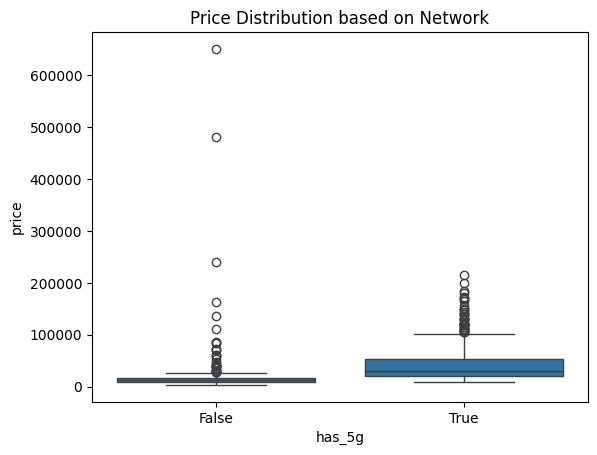

In [ ]:
sns.boxplot(df,x = 'has_5g',y = 'price')
plt.title("Price Distribution based on Network")

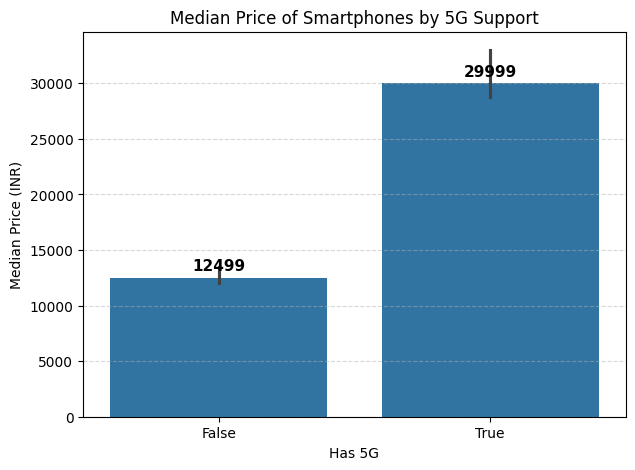

In [ ]:
plt.figure(figsize=(7, 5))
bar = sns.barplot(x='has_5g', y='price', data=df, estimator=np.median)
plt.title('Median Price of Smartphones by 5G Support')
plt.xlabel('Has 5G')
plt.ylabel('Median Price (INR)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
# Add value labels using bar.containers (matplotlib 3.4+)
for container in bar.containers:
    bar.bar_label(container, fmt='%.0f', padding=3, fontsize=11, fontweight='bold')

plt.show()

### price vs has_nfc

- Smartphones with NFC support have a significantly higher median price compared to those without NFC.

- The boxplot reveals that NFC-enabled devices not only cluster at higher prices but also have a wider distribution and more extreme high-end outliers.

- Non-NFC phones generally stay in the lower and mid price range, with very few reaching premium levels.

- Result: NFC is mostly present in mid-range and flagship smartphones in your dataset, making it a marker of advanced or premium models.

In [ ]:
df.groupby('has_nfc')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
has_nfc,,,,,,,,
False,589.0,17236.879457,14485.301352,3499.0,10499.00,14590.0,19990.0,199990.0
True,392.0,55328.344388,52238.938131,8990.0,26996.75,40994.5,69990.0,650000.0


Text(0.5, 1.0, 'Price Distribution based on NFC')

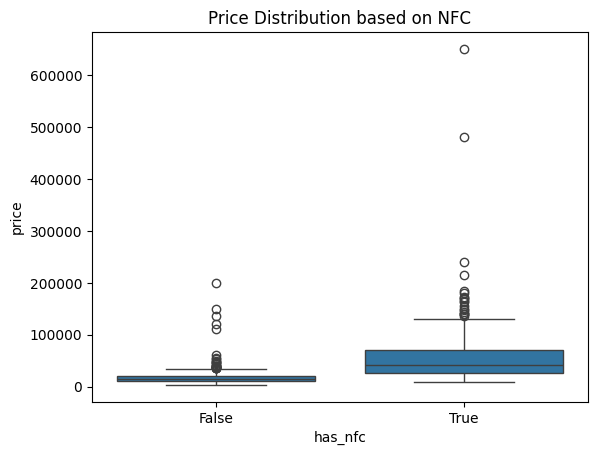

In [ ]:
sns.boxplot(df,x = 'has_nfc',y = 'price')
plt.title("Price Distribution based on NFC")

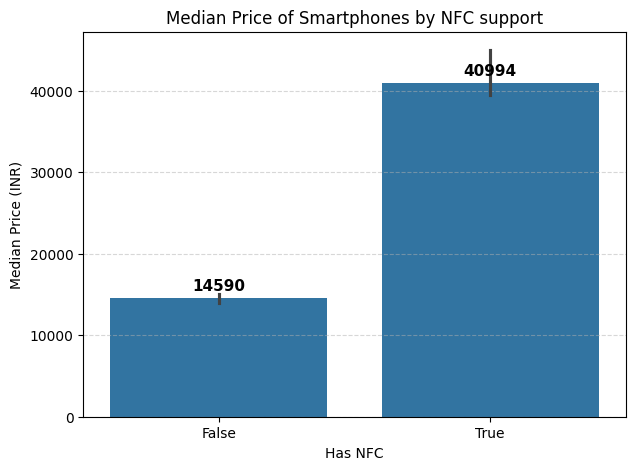

In [ ]:
plt.figure(figsize=(7, 5))
bar = sns.barplot(x='has_nfc', y='price', data=df, estimator=np.median)
plt.title('Median Price of Smartphones by NFC support')
plt.xlabel('Has NFC')
plt.ylabel('Median Price (INR)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
# Add value labels using bar.containers (matplotlib 3.4+)
for container in bar.containers:
    bar.bar_label(container, fmt='%.0f', padding=3, fontsize=11, fontweight='bold')

plt.show()

### price vs has_ir_blaster

- The median price is nearly the same for phones with and without IR blaster.

- Price distributions (min, max, outliers) are similar between the two groups.

- Xiaomi dominates the IR blaster segment, followed by brands like Poco, POCO, iQOO, Huawei, Vivo, Redmi, Honor, and Samsung.

- IR blaster is mostly absent in non-Chinese/global premium brands.

- The feature is not linked to high-end devices and is common in mainstream affordable and mid-range smartphones.

- Having an IR blaster does not make phones more expensive.

In [ ]:
df.groupby('has_ir_blaster')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
has_ir_blaster,,,,,,,,
False,822.0,32720.357664,40680.469460,3499.0,12571.75,19990.0,36694.75,650000.0
True,159.0,31101.251572,33075.859953,9990.0,13999.00,19999.0,31990.00,239999.0


Text(0.5, 1.0, 'Price Distribution based on IR Blaster')

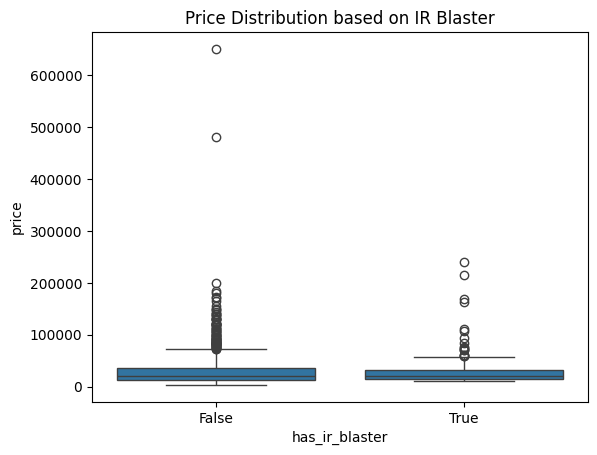

In [ ]:
sns.boxplot(df,x = 'has_ir_blaster',y = 'price')
plt.title("Price Distribution based on IR Blaster")

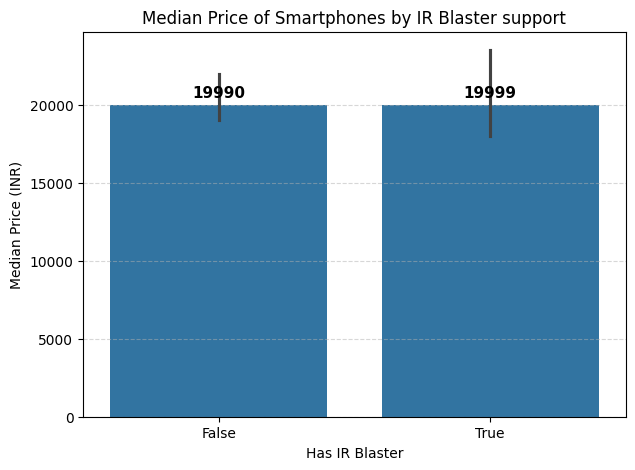

In [ ]:
plt.figure(figsize=(7, 5))
bar = sns.barplot(x='has_ir_blaster', y='price', data=df, estimator=np.median)
plt.title('Median Price of Smartphones by IR Blaster support')
plt.xlabel('Has IR Blaster')
plt.ylabel('Median Price (INR)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
# Add value labels using bar.containers (matplotlib 3.4+)
for container in bar.containers:
    bar.bar_label(container, fmt='%.0f', padding=3, fontsize=11, fontweight='bold')

plt.show()

In [ ]:
df[df['has_ir_blaster']==True]['brand_name'].value_counts()

,count
brand_name,
Xiaomi,109
Poco,30
iQOO,6
Huawei,6
Vivo,4
Redmi,2
Honor,1
Samsung,1


In [ ]:
temp_ir = df[df['has_ir_blaster'] == True]['brand_name'].value_counts()


In [ ]:
temp_ir = temp_ir.reset_index()

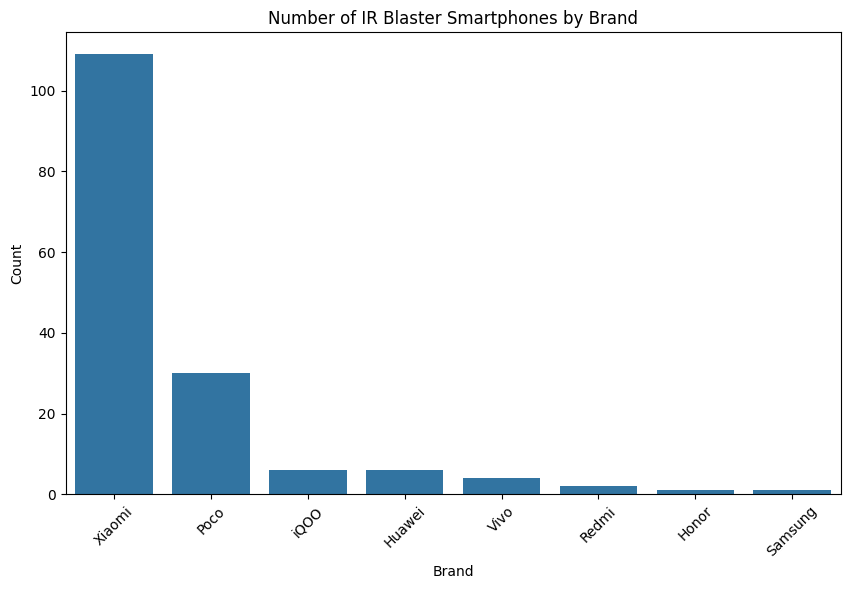

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=temp_ir, x='brand_name', y='count', order=temp_ir['brand_name'])
plt.title("Number of IR Blaster Smartphones by Brand")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### price vs ram_capacity

- Most phones with higher RAM have higher prices.

- Maximum phones are clustered in the 48GB RAM and 10,00050,000 price range.

- A few outliers existultra-expensive phones that don't follow the general RAM-price pattern.

- After around 12GB RAM, price increases less sharply, suggesting other features drive cost.

- Budget smartphones with 24GB RAM cost below 20,000.

- High RAM (12GB+) models are rare and mostly premium/gaming devices.

In [ ]:
df.groupby('ram_capacity')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
ram_capacity,,,,,,,,
1.0,7.0,5923.714286,1204.890550,3999.0,5244.50,5990.0,6744.50,7499.0
2.0,31.0,27586.096774,115523.365199,4499.0,6210.00,6499.0,7555.00,650000.0
3.0,54.0,10723.277778,8348.535713,3499.0,7324.00,8724.5,9999.00,52990.0
4.0,216.0,15786.791667,13756.671877,4990.0,9999.00,12489.5,14999.00,109900.0
6.0,234.0,29306.649573,33310.847576,5999.0,14990.00,17999.0,24947.50,182999.0
8.0,338.0,38450.186391,34919.531831,10999.0,21991.00,28990.0,42990.00,480000.0
12.0,85.0,70945.129412,38481.482349,22990.0,42990.00,59990.0,92999.00,214990.0
16.0,9.0,62330.333333,20765.133415,39999.0,45999.00,59999.0,69999.00,107990.0
18.0,2.0,82994.500000,9905.858898,75990.0,79492.25,82994.5,86496.75,89999.0


In [ ]:
df['price'].corr(df['ram_capacity'])

np.float64(0.3829727615161312)

Text(0.5, 1.0, 'Price vs Ram Distribution')

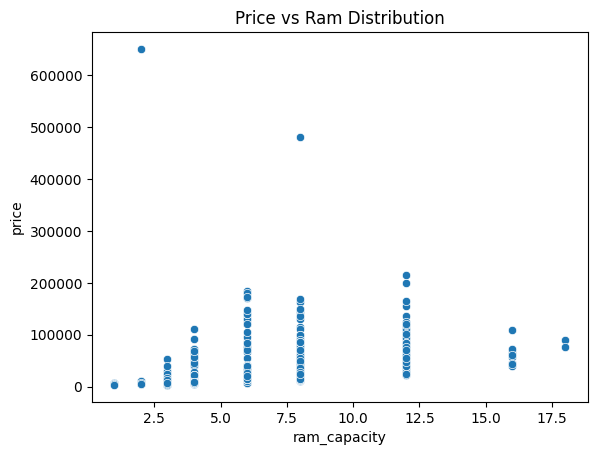

In [ ]:
sns.scatterplot(df,x='ram_capacity',y='price')
plt.title("Price vs Ram Distribution")

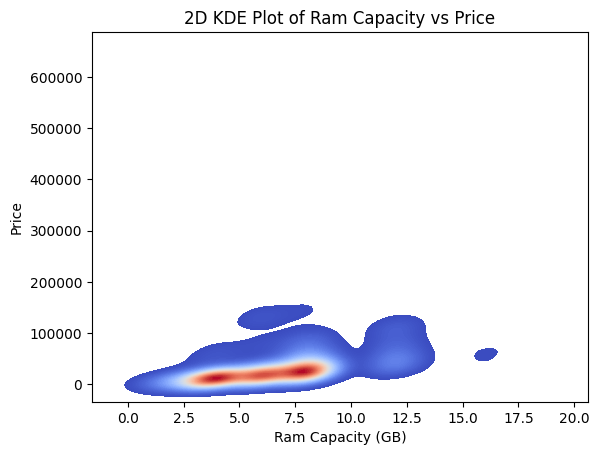

In [ ]:
sns.kdeplot(
    data=df,
    x='ram_capacity',
    y='price',
    fill=True,          # fills the color
    cmap='coolwarm',    # color scheme
    levels=100         # smoothness (more = smoother)
)
plt.title("2D KDE Plot of Ram Capacity vs Price")
plt.xlabel("Ram Capacity (GB)")
plt.ylabel("Price")
plt.show()

### price vs storage_capacity


- Most of the phones have 128gb storage.
- The price and storage are strongly correlated.
- Most of the phones from 64 GB to 128GB are clustered at the price range of 10k to 50k

In [ ]:
df[['storage_capacity', ]].describe()

,storage_capacity
count,979.000000
mean,141.037794
std,107.203463
min,4.000000
25%,64.000000
50%,128.000000
75%,128.000000
max,1024.000000


In [ ]:
df['price'].corr(df['storage_capacity'])

np.float64(0.5573404708724066)

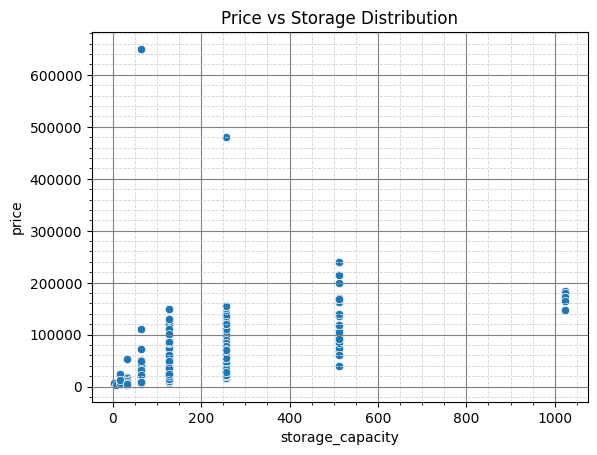

In [ ]:
sns.scatterplot(df,x = 'storage_capacity',y = 'price')
plt.title("Price vs Storage Distribution")

plt.minorticks_on()  # enables minor ticks

# Add grid for both
plt.grid(which='major', color='gray', linewidth=0.8)
plt.grid(which='minor', color='lightgray', linestyle='--', linewidth=0.6)

plt.show()

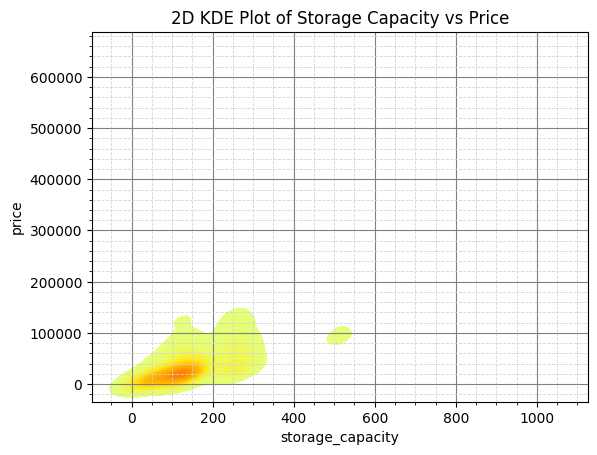

In [ ]:
sns.kdeplot(df,x = 'storage_capacity',y = 'price',fill = True,cmap = 'Wistia', levels = 100)
plt.title("2D KDE Plot of Storage Capacity vs Price")

plt.minorticks_on()  # enables minor ticks

# Add grid for both
plt.grid(which='major', color='gray', linewidth=0.8)
plt.grid(which='minor', color='lightgray', linestyle='--', linewidth=0.6)

plt.show()

In [ ]:
df[(df['storage_capacity']>0) & (df['storage_capacity']<200)]['storage_capacity'].value_counts()

,count
storage_capacity,
128.0,522
64.0,193
32.0,67
16.0,11
4.0,1
8.0,1


### Numerical VS Numerical Analysis

In [ ]:
def numVSnum(df, col1, col2):

    corr = df[col1].corr(df[col2])
    print(f"\nCorrelation between {col1} and {col2}: {corr:.2f}\n")

    # Plot side by side
    plt.figure(figsize=(10, 8))

    # Scatter plot
    plt.subplot(2, 2, 1)
    plt.scatter(df[col1], df[col2], alpha=0.5)
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.title(f"Scatter Plot: {col1} vs {col2}")
    plt.minorticks_on()

    plt.grid(which='major', color='gray', linewidth=0.8)
    plt.grid(which='minor', color='lightgray', linestyle='--', linewidth=0.6)


    # KDE plot
    plt.subplot(2, 2, 2)
    sns.kdeplot(data=df, x=col1, y=col2, fill=True, cmap="coolwarm")
    plt.title(f"Density Plot: {col1} vs {col2}")

    plt.tight_layout()

    plt.minorticks_on()

    plt.grid(which='major', color='gray', linewidth=0.8)
    plt.grid(which='minor', color='lightgray', linestyle='--', linewidth=0.6)

    plt.show()


### Price vs Processor Core

- There is no strong correlation between processor_core and price (r= 0.07
) core count does not predict price.

- 4-core phones are mostly budget models with low mean/median prices.

- 6-core phones are mainly premium, with the highest mean and widest spread of prices.

- 8-core phones are most common, found at all price rangesfrom budget to flagship models.

- High-priced outliers exist for all core categories, but 8-core phones dominate in numbers.

- Processor_core is not a reliable feature to distinguish phone pricing. Other specifications and brand factors have a bigger impact.

- Most of the market utilizes 8-core processors for both affordable and high-end devices.


Correlation between processor_core and price: -0.07



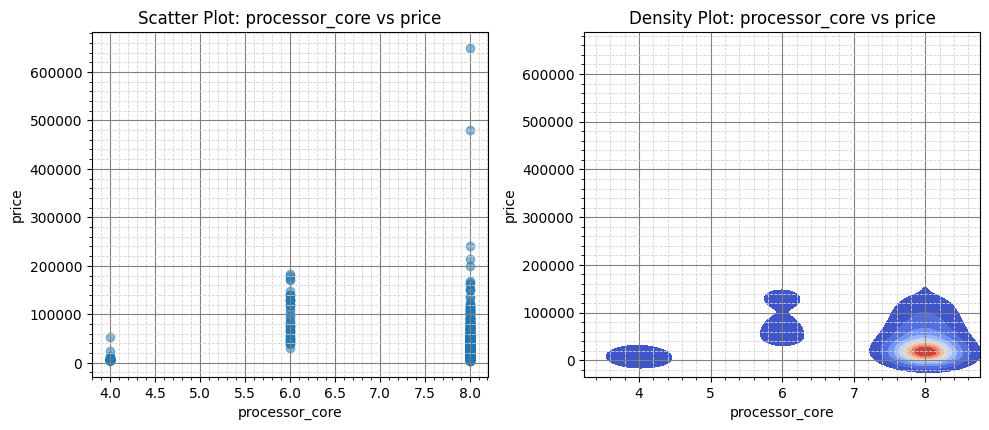

In [ ]:
numVSnum(df,'processor_core','price')

### price vs processor_speed

- There is a clear positive relationship: higher processor speed is generally associated with higher smartphone prices.

- Most phones cluster between 23 GHz processor speed and below 100,000.

- The density plot shows that the most common devices have processor speeds in this range, with moderate pricing.

- Some outliers exist with very high prices at both medium and high processor speeds.

- Faster processors generally cost more, but other specs and brand factors also strongly affect price.


Correlation between processor_speed and price: 0.47



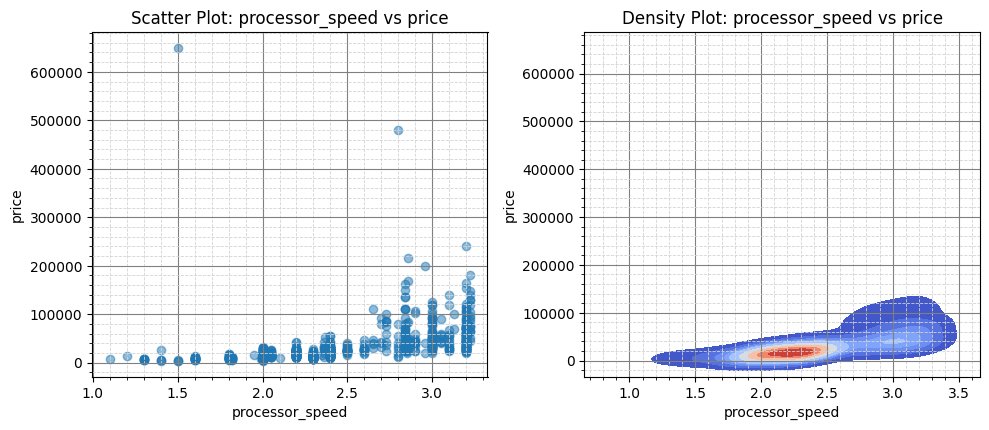

In [ ]:
numVSnum(df,'processor_speed','price')

### price vs battery_capacity

- There is a very weak negative relationship: higher battery capacity is slightly associated with lower smartphone prices, but the effect is minimal.

- Most phones cluster between 30006000 mAh battery capacity and below 100,000 in price.

- The density plot shows most common devices have battery capacities in this range, with a wide range of prices.

- Some outliers exist with very high prices and both medium and high battery capacities.

- Battery capacity does not strongly affect price; other specs and brand factors have a much bigger influence.


Correlation between battery_capacity and price: -0.15



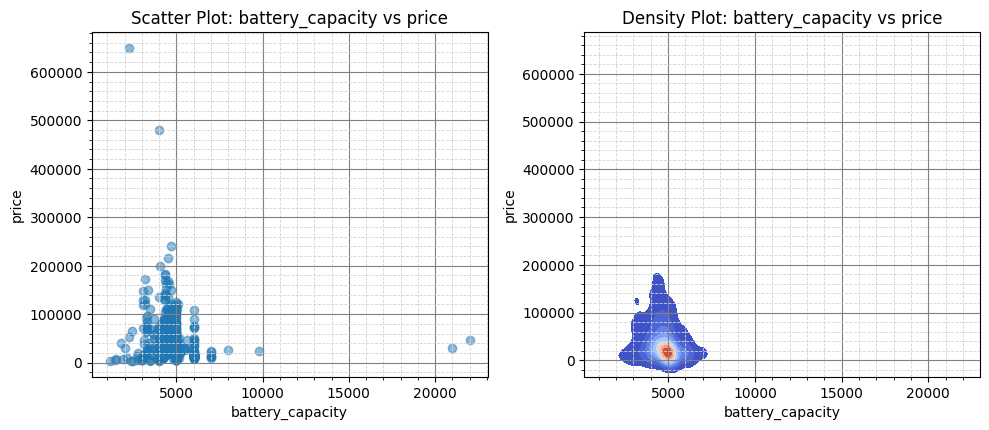

In [ ]:
numVSnum(df,'battery_capacity','price')

### price vs fast charging
- There is a weak positive relationship: higher fast charging speeds (r=0.28) are generally associated with higher smartphone prices.

- Most phones cluster between 1060W fast charging and below 100,000 in price.

- The density plot shows most common devices offer fast charging in this range, with moderate pricing.

- Outliers exist, some with very high prices and both medium or very high fast charging rates.

- Fast charging capability tends to raise price, but brand and other specs also heavily influence overall price.


Correlation between fast_charging and price: 0.28



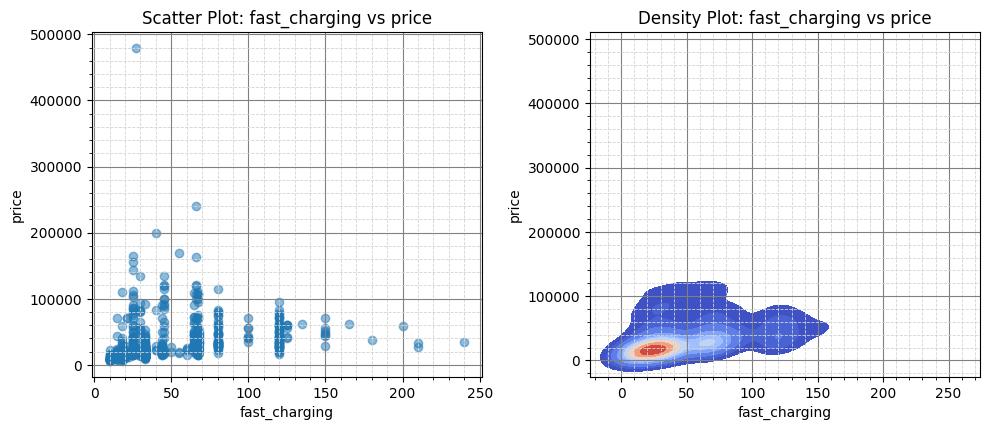

In [ ]:
numVSnum(df,'fast_charging','price')

### price vs display_size

There is a very weak positive relationship: larger display size (r=0.12) is only slightly associated with higher smartphone prices.

Most phones cluster between 67 inches display size and below 100,000 in price.

The density plot shows that the majority of devices have display sizes in this range, regardless of price.

Some outliers exist with high prices and larger displays, but overall the relationship is weak.

Display size does not strongly impact price; other specifications and brand factors are more important.


Correlation between display_size and price: 0.12



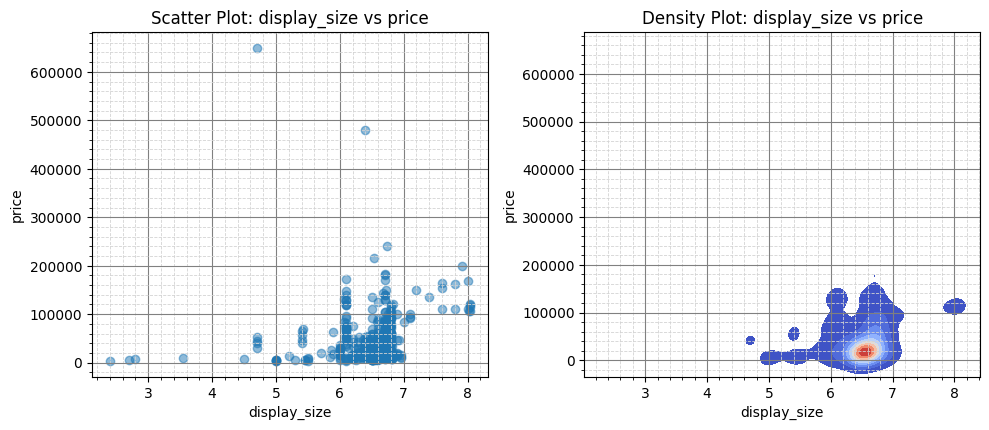

In [ ]:
numVSnum(df,'display_size','price')

### Price VS refresh_rate

- There is little bit positive correlation ( r = 0.25 ) butween price and refresh rate.
- Most of the low to average price phones have 60Hz refresh rate.
- The price of The phones range from mid to high have 120Hz refresh rate too.
- There are some outliers which have more than 225 refresh rate and some which have only 60Hz refresh rate but price booms high.



Correlation between refresh_rate and price: 0.25



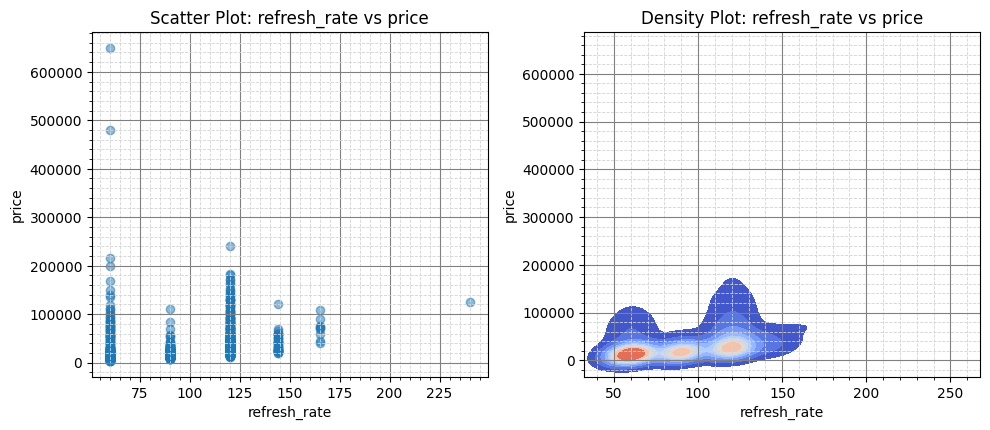

In [ ]:
numVSnum(df,'refresh_rate','price')

### price vs max_rear_camera_MP
- There is a heavy cluster of phones having 50 MP camera ranging from 10K to 40K.
- The correlation coefficient between max_rear_camera_MP and price is 0.10, indicating a very weak positive relationship.
- Both the scatter and density plots show a wide price range for all camera MP values, with no clear increasing trend.
- Having a higher MP camera does not guarantee a higher price.
- Pricing is likely influenced by other features (brand, processor, RAM, display, etc.), not just the maximum rear camera MP.


Correlation between max_rear_camera_MP and price: 0.10



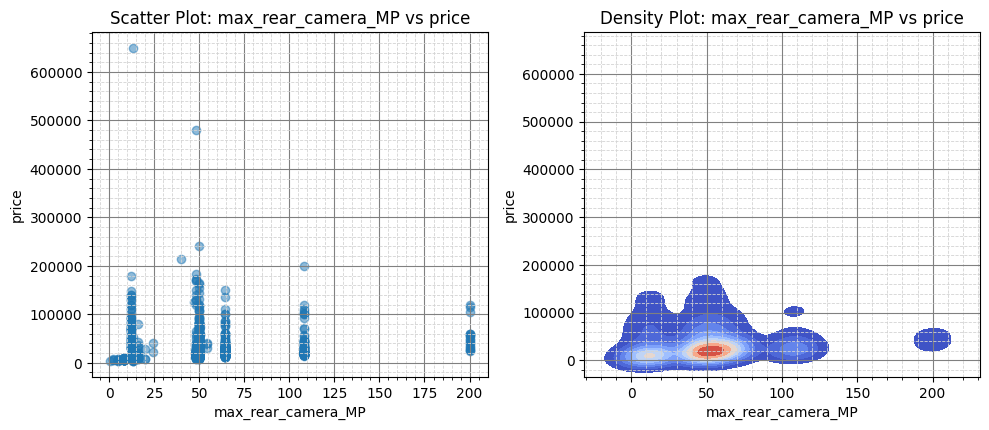

In [ ]:
numVSnum(df,'max_rear_camera_MP','price')

### price vs max_front_camera_MP

1. The correlation coefficient between max_front_camera_MP and price is 0.16, indicating a weak positive relationship.
2. Both the scatter and density plots show that higher front camera MP does not consistently correspond to higher prices; wide price variations occur at all MP levels.
3. Upgrading to a higher front camera MP does not ensure a higher price for smartphones.
4. The price is likely determined by a combination of features rather than just the maximum front camera MP.


Correlation between max_front_camera_MP and price: 0.16



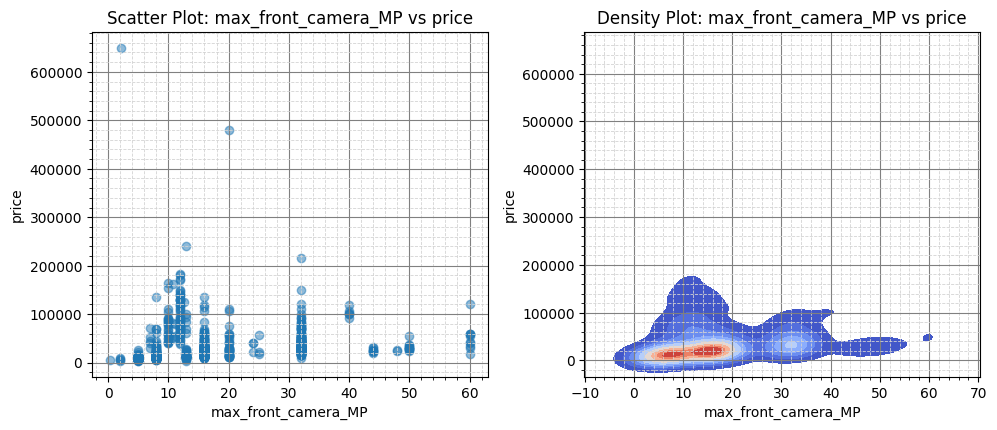

In [ ]:
numVSnum(df,'max_front_camera_MP','price')

### price vs card_supported

- There is a moderate negative correlation (r=0.45) between card support and price.

- Phones without card support are generally much more expensive, as seen in the boxplot, histogram, and density plots.

- Card-supported phones are mostly low- to mid-priced; premium models rarely offer card slots.

- Key takeaway: Lack of card support strongly indicates a premium or flagship smartphone.


Correlation between card_supported and price: -0.45



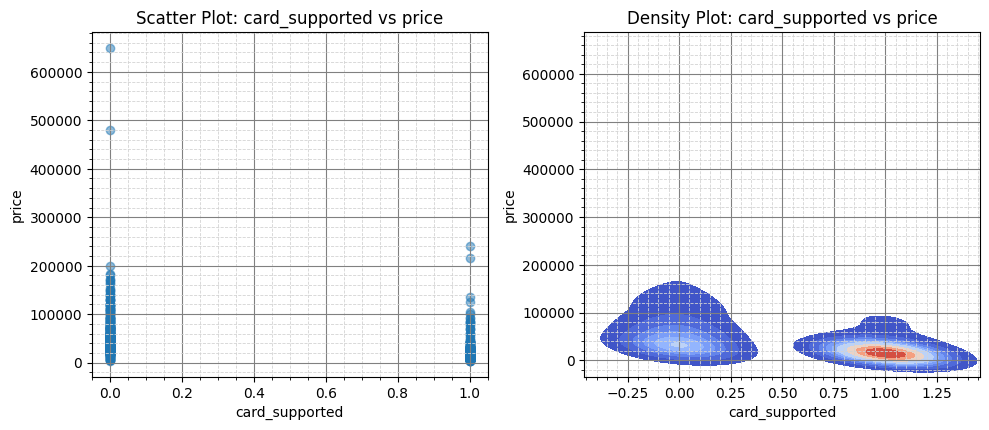

In [ ]:
numVSnum(df,'card_supported','price')

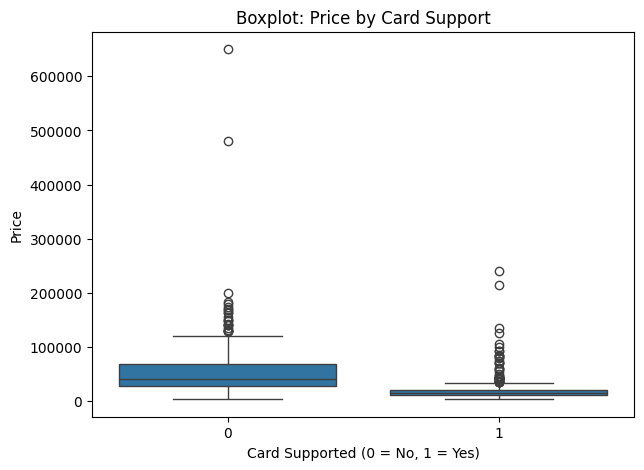

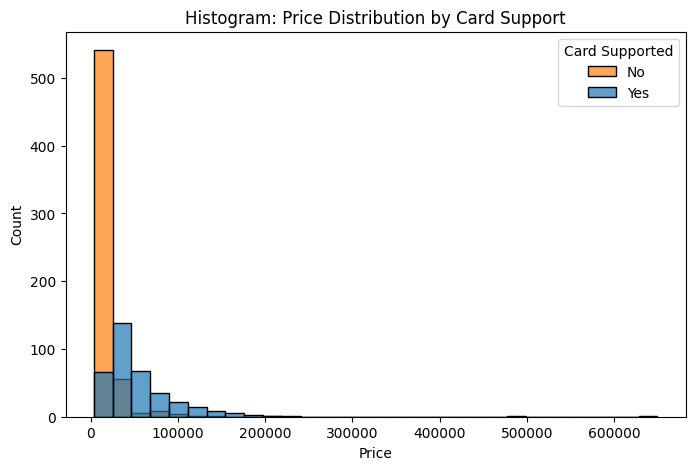

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x='card_supported', y='price', data=df)
plt.title('Boxplot: Price by Card Support')
plt.xlabel('Card Supported (0 = No, 1 = Yes)')
plt.ylabel('Price')
plt.show()

# Histogram: Price split by Card Support Type
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='price', hue='card_supported', bins=30, kde=False, alpha=0.7)
plt.title('Histogram: Price Distribution by Card Support')
plt.xlabel('Price')
plt.ylabel('Count')
plt.legend(title='Card Supported', labels=['No', 'Yes'])
plt.show()

### price vs resolution_type

**Conclusion:**

- **2K / QHD (1440p)** smartphones have the **highest average price** (79,958) and median (73,999), indicating they are positioned in the **premium segment**.

- **Full HD (1080p)** is the **most common resolution type** (662 phones), with a wide price range from 16,499 to 65,000, indicating it serves both **mid-range and flagship** markets.

- **HD (720p)** phones have a lower average price (12,045) and median (9,999), positioned in the **budget to entry-level segment**.

- **Below HD** phones are the **most affordable** (mean: 5,968, median: 5,490), representing the **ultra-budget category** with minimal market presence (only 8 phones).

- There is a **clear positive correlation** between resolution type and price: higher resolution smartphones consistently command **higher prices**, reflecting their premium display quality and overall specifications.

In [ ]:
df.groupby('resolution_type')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
resolution_type,,,,,,,,
2K / QHD (1440p),77.0,79957.688312,36066.274753,15990.0,54999.0,73999.0,99999.00,199990.0
Below HD,8.0,5967.875000,2113.748764,3589.0,4590.0,5490.0,7049.00,9990.0
Full HD (1080p),662.0,34468.590634,41505.488023,3890.0,16499.0,23134.0,35867.25,650000.0
HD (720p),234.0,12045.047009,7957.493537,3499.0,7999.0,9999.0,13499.00,71999.0


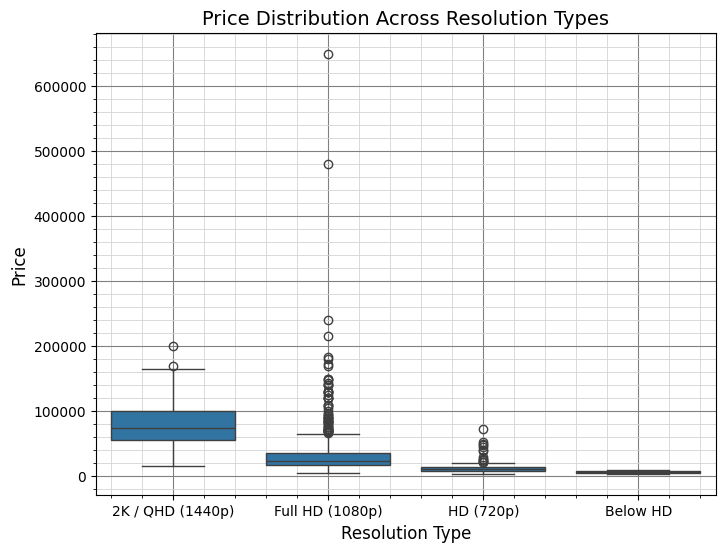

In [ ]:
plt.figure(figsize = (8,6))
sns.boxplot(data=df, x='resolution_type', y='price')

plt.minorticks_on()

plt.grid(which='major', linewidth=0.8, color='grey')
plt.grid(which='minor', linewidth=0.6, color='lightgrey')

plt.title("Price Distribution Across Resolution Types", fontsize=14)
plt.xlabel("Resolution Type", fontsize=12)
plt.ylabel("Price", fontsize=12)

plt.show()


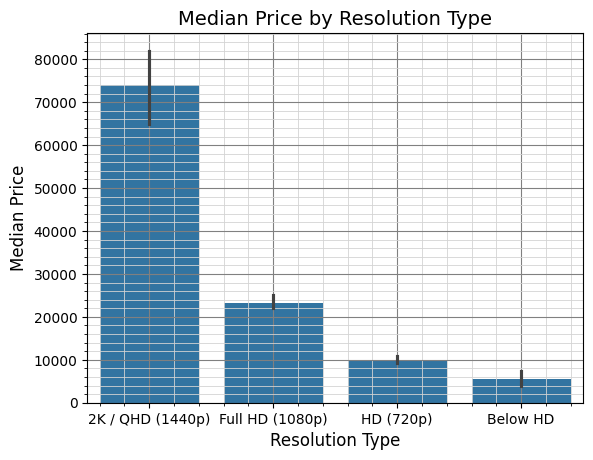

In [ ]:
sns.barplot(data=df, x='resolution_type', y='price', estimator=np.median)

plt.minorticks_on()

plt.grid(which='major', linewidth=0.8, color='grey')
plt.grid(which='minor', linewidth=0.6, color='lightgrey')

plt.title("Median Price by Resolution Type", fontsize=14)
plt.xlabel("Resolution Type", fontsize=12)
plt.ylabel("Median Price", fontsize=12)

plt.show()


### brand_name vs rating

- Premium brands (OnePlus, Apple, Samsung, Huawei, Google) generally achieve higher and more consistent ratings, reflecting strong user satisfaction and product quality.
- Mid-tier brands (Realme, Xiaomi, Oppo, Vivo, Motorola) show moderate ratings with more variability, suggesting a mix of strong and average-performing models.
- Budget brands (Tecno, Infinix, Nokia, Honor, POCO) exhibit lower ratings and greater spread, indicating inconsistent performance and more negative outliers.
- Overall, brand reputation aligns well with user ratings, confirming that consumers tend to favor established premium brands for reliable satisfaction.

In [ ]:
brands_over_10 = df['brand_name'].value_counts()
brands_over_10 = brands_over_10[brands_over_10 > 10].index

brand_df = df[df['brand_name'].isin(brands_over_10)]


In [ ]:
brand_df

,brand_name,model,price,rating,sim_type,has_5g,has_nfc,has_ir_blaster,ram_capacity,storage_capacity,processor_core,processor_speed,battery_capacity,fast_charging,display_size,resolution,refresh_rate,no_of_rear_camera,no_of_front_camera,max_rear_camera_MP,max_front_camera_MP,card_supported,os,resolution_type
0,OnePlus,OnePlus 11 5G,54999,89.0,Dual Sim,True,True,False,12.0,256.0,8.0,3.20,5000.0,100.0,6.70,1440 x 3216,120,3,1,50.0,16.0,0,Android v13,2K / QHD (1440p)
1,OnePlus,OnePlus Nord CE 2 Lite 5G,19989,81.0,Dual Sim,True,False,False,6.0,128.0,8.0,2.20,5000.0,33.0,6.59,1080 x 2412,120,3,1,64.0,16.0,1,Android v12,Full HD (1080p)
2,Samsung,Samsung Galaxy A14 5G,16499,75.0,Dual Sim,True,False,False,4.0,64.0,8.0,2.40,5000.0,15.0,6.60,1080 x 2408,90,3,1,50.0,13.0,1,Android v13,Full HD (1080p)
3,Motorola,Motorola Moto G62 5G,14999,81.0,Dual Sim,True,False,False,6.0,128.0,8.0,2.20,5000.0,NaN,6.55,1080 x 2400,120,3,1,50.0,16.0,1,Android v12,Full HD (1080p)
4,Realme,Realme 10 Pro Plus,24999,82.0,Dual Sim,True,False,False,6.0,128.0,8.0,2.60,5000.0,67.0,6.70,1080 x 2412,120,3,1,108.0,16.0,0,Android v13,Full HD (1080p)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015,Motorola,Motorola Moto Edge S30 Pro,34990,83.0,Dual Sim,True,False,False,8.0,128.0,8.0,3.00,5000.0,68.2,6.67,1080 x 2460,120,3,1,64.0,16.0,0,Android v12,Full HD (1080p)
1016,Honor,Honor X8 5G,14990,75.0,Dual Sim,True,False,False,6.0,128.0,8.0,2.20,5000.0,22.5,6.50,720 x 1600,60,3,1,48.0,8.0,1,Android v11,HD (720p)
1017,Poco,POCO X4 GT 5G (8GB RAM + 256GB),28990,85.0,Dual Sim,True,True,True,8.0,256.0,8.0,2.85,5080.0,67.0,6.60,1080 x 2460,144,3,1,64.0,16.0,0,Android v12,Full HD (1080p)
1018,Motorola,Motorola Moto G91 5G,19990,80.0,Dual Sim,True,True,False,6.0,128.0,8.0,2.20,5000.0,NaN,6.80,1080 x 2400,60,3,1,108.0,32.0,1,Android v12,Full HD (1080p)


In [ ]:
brand_df.groupby('brand_name')['rating'].describe()

,count,mean,std,min,25%,50%,75%,max
brand_name,,,,,,,,
Apple,44.0,76.795455,6.249017,60.0,75.00,77.5,81.25,86.0
Google,12.0,77.333333,7.240459,67.0,70.50,78.0,82.50,89.0
Honor,11.0,78.181818,6.368959,68.0,75.00,76.0,83.00,88.0
Huawei,11.0,80.000000,8.012490,63.0,81.00,82.0,84.00,89.0
Infinix,28.0,76.285714,7.427961,60.0,72.75,77.0,80.75,89.0
Motorola,48.0,80.104167,6.627601,65.0,75.75,81.0,85.00,89.0
Nokia,10.0,75.300000,8.564137,62.0,70.25,75.5,81.75,87.0
OnePlus,38.0,82.236842,5.180182,68.0,81.00,84.0,85.00,89.0
Oppo,81.0,78.679012,7.068994,62.0,73.00,80.0,84.00,89.0


/tmp/ipython-input-497528201.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='brand_name', y='rating', data=brand_df, palette='Set2')


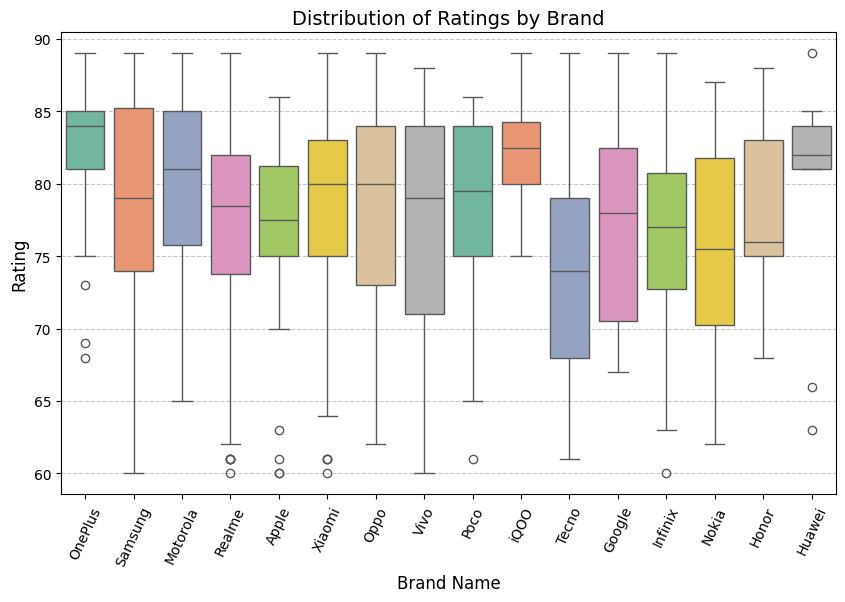

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='brand_name', y='rating', data=brand_df, palette='Set2')

plt.title("Distribution of Ratings by Brand", fontsize=14)
plt.xlabel("Brand Name", fontsize=12)
plt.ylabel("Rating", fontsize=12)
plt.xticks(rotation=65)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'OnePlus'),
  Text(1, 0, 'Samsung'),
  Text(2, 0, 'Motorola'),
  Text(3, 0, 'Realme'),
  Text(4, 0, 'Apple'),
  Text(5, 0, 'Xiaomi'),
  Text(6, 0, 'Oppo'),
  Text(7, 0, 'Vivo'),
  Text(8, 0, 'Poco'),
  Text(9, 0, 'iQOO'),
  Text(10, 0, 'Tecno'),
  Text(11, 0, 'Google'),
  Text(12, 0, 'Infinix'),
  Text(13, 0, 'Nokia'),
  Text(14, 0, 'Honor'),
  Text(15, 0, 'Huawei')])

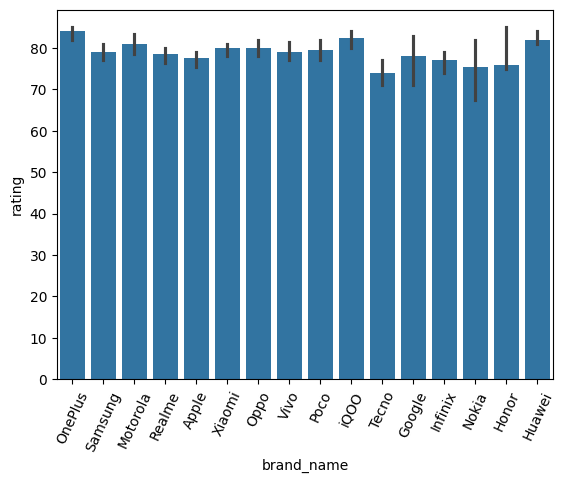

In [ ]:
sns.barplot(x='brand_name', y='rating', data=brand_df, estimator=np.median)
plt.xticks(rotation = 65)

In [ ]:
# Example mapping for Indian/global market
brand_segment = {
    'Apple': 'Premium',
    'Samsung': 'Premium',
    'OnePlus': 'Premium',
    'Google': 'Premium',
    'Huawei': 'Premium',
    'Xiaomi': 'Mid-tier',
    'Realme': 'Mid-tier',
    'Oppo': 'Mid-tier',
    'Vivo': 'Mid-tier',
    'Motorola': 'Mid-tier',
    'POCO': 'Budget',
    'Tecno': 'Budget',
    'Infinix': 'Budget',
    'Nokia': 'Budget',
    'Honor': 'Budget',
    # Add other brands accordingly
}
brand_df['segment'] = brand_df['brand_name'].map(brand_segment)


/tmp/ipython-input-1762586719.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brand_df['segment'] = brand_df['brand_name'].map(brand_segment)


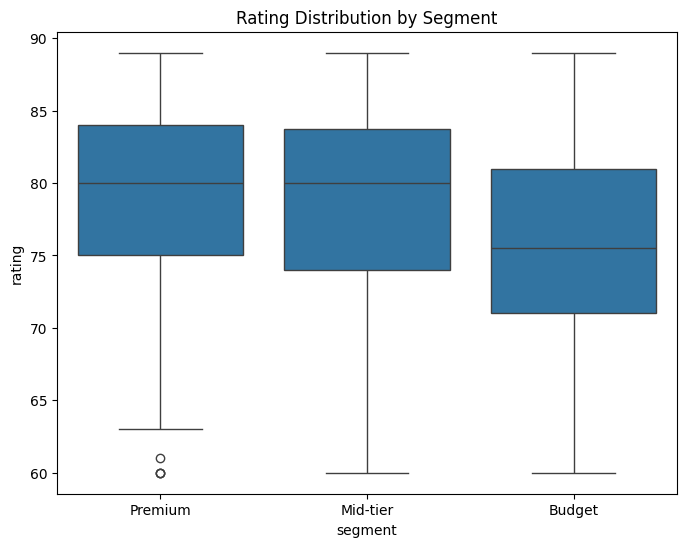

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='segment', y='rating', data=brand_df)
plt.title('Rating Distribution by Segment')
plt.show()

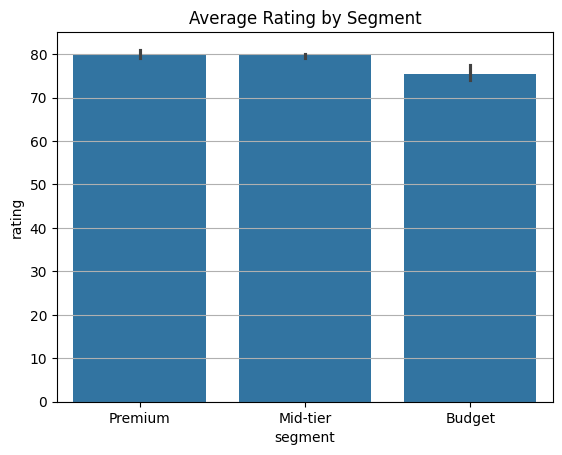

In [ ]:
sns.barplot(x='segment', y='rating', data=brand_df, estimator=np.median)
plt.title('Average Rating by Segment')
plt.grid(axis = 'y')
plt.show()


<Axes: xlabel='segment', ylabel='rating'>

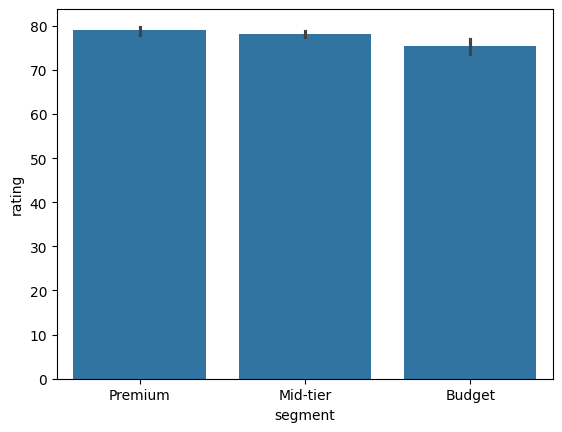

In [ ]:
sns.barplot(data = brand_df,x='segment',y='rating')

### brand_name vs sim_type

- Except Vertu, almost all the phones have dual sim.
- So we can say most of the phones use dual sim.

In [ ]:
pd.crosstab(brand_df['sim_type'], brand_df['brand_name'])

brand_name,Apple,Google,Honor,Huawei,Infinix,Motorola,Nokia,OnePlus,Oppo,Poco,Realme,Samsung,Tecno,Vivo,Xiaomi,iQOO
sim_type,,,,,,,,,,,,,,,,
Dual Sim,44,11,13,16,29,51,15,42,84,41,97,130,33,111,134,32
Single Sim,2,3,0,0,0,1,1,0,3,0,0,2,0,0,0,0


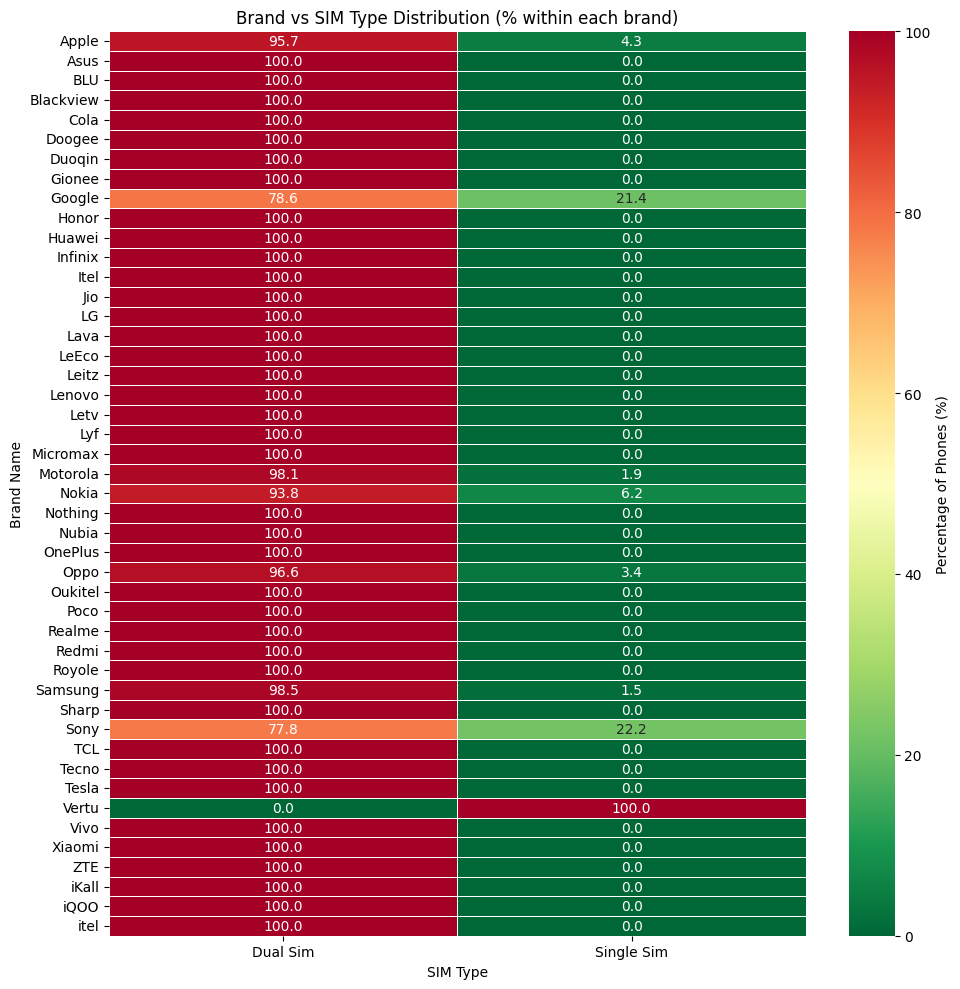

In [ ]:
# Create crosstab with row-wise normalization (percentage within each brand)
sim_brand = pd.crosstab(df['brand_name'], df['sim_type'], normalize='index') * 100

# Plot heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(sim_brand, annot=True, fmt='.1f',  # Show percentages with 1 decimal
            cmap='RdYlGn_r',  # Red-Yellow-Green reversed
            linewidths=0.5,
            cbar_kws={'label': 'Percentage of Phones (%)'},
            vmin=0, vmax=100)  # Percentage scale from 0 to 100
plt.title('Brand vs SIM Type Distribution (% within each brand)')
plt.xlabel('SIM Type')
plt.ylabel('Brand Name')
plt.tight_layout()
plt.show()


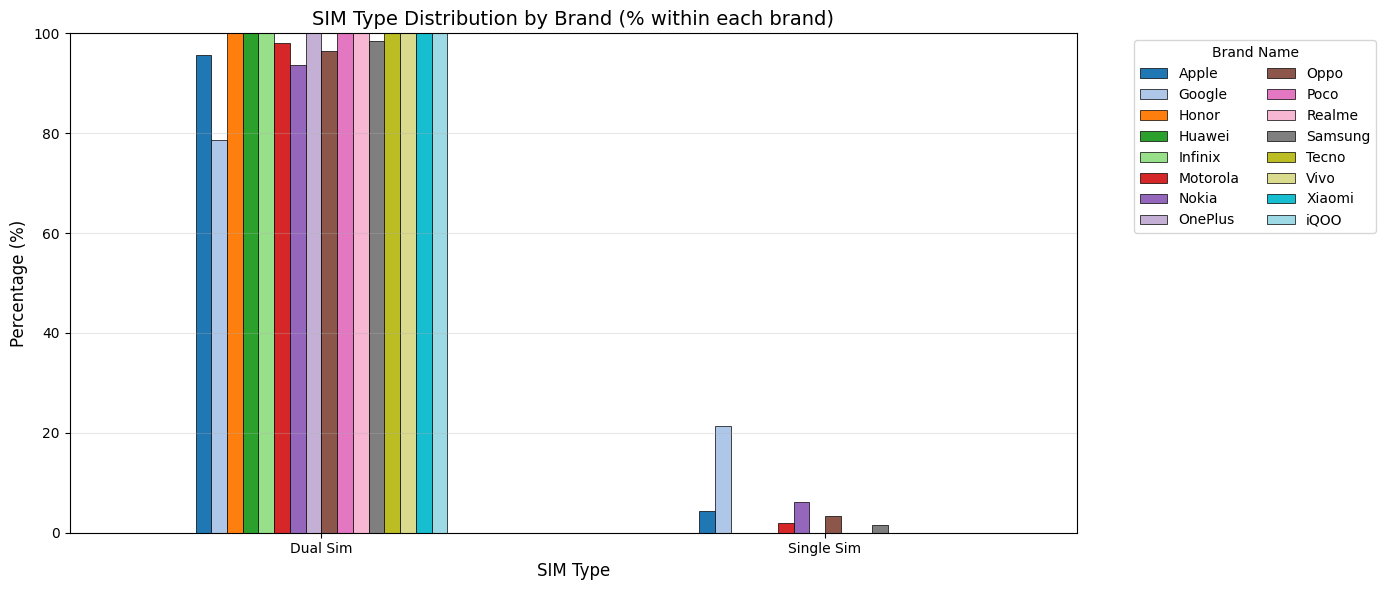

In [ ]:
sim_brand_pct = pd.crosstab(brand_df['sim_type'],
                            brand_df['brand_name'],
                            normalize='columns') * 100  # Column-wise normalization
sim_brand_pct.plot(kind='bar',
                   figsize=(14, 6),
                   colormap='tab20',
                   edgecolor='black',
                   linewidth=0.5)

plt.title('SIM Type Distribution by Brand (% within each brand)', fontsize=14)
plt.xlabel('SIM Type', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Brand Name', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


#### brand_name vs has_5g
- Apple, OnePlus,IQOO and Google has most numbers of phone having 5G.
- Huawei and Techno phones have least number of phones having 5G.


In [ ]:
ct = pd.crosstab(brand_df['brand_name'],brand_df['has_5g'],normalize = 'index')*100
ct

has_5g,False,True
brand_name,,
Apple,19.565217,80.434783
Google,21.428571,78.571429
Honor,23.076923,76.923077
Huawei,75.000000,25.000000
Infinix,75.862069,24.137931
Motorola,38.461538,61.538462
Nokia,56.250000,43.750000
OnePlus,14.285714,85.714286
Oppo,40.229885,59.770115


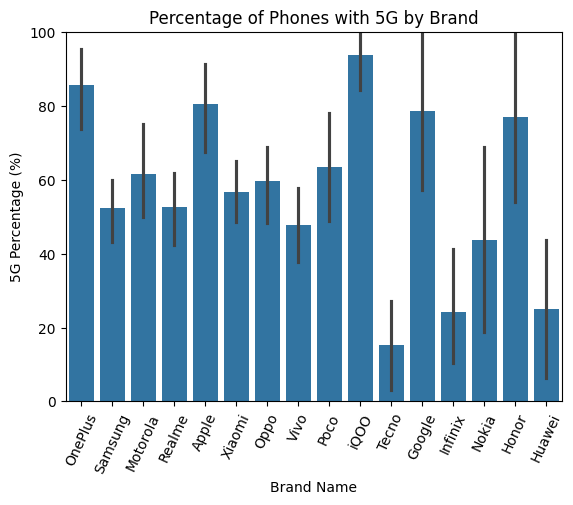

In [ ]:
sns.barplot(
    data=brand_df,
    x='brand_name',
    y='has_5g',
    estimator=lambda x: x.mean() * 100,
)

plt.xticks(rotation=65)
plt.title('Percentage of Phones with 5G by Brand')
plt.xlabel("Brand Name")
plt.ylabel("5G Percentage (%)")
plt.ylim(0, 100)
plt.show()


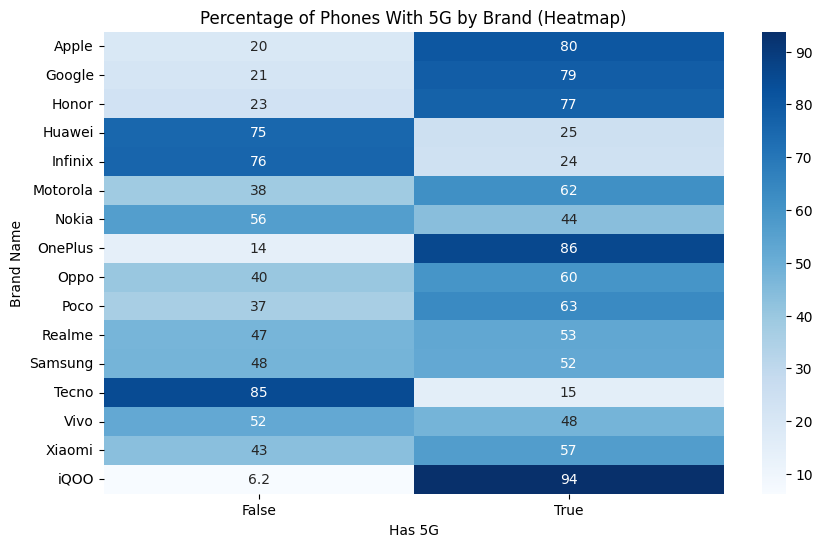

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(ct, annot=True, cmap="Blues")
plt.title("Percentage of Phones With 5G by Brand (Heatmap)")
plt.ylabel("Brand Name")
plt.xlabel("Has 5G")
plt.show()

#### brand_name vs has_nfc

- NFC adoption shows a **much more widespread** implementation across brands compared to IR Blaster
- Most modern smartphones across all price segments now include NFC as a standard feature
- **Premium and mid-range brands** show near-universal NFC adoption (90%+ in most cases)
- **Apple** and **Google** lead with most number of nfc in their phones.


In [ ]:
ct = pd.crosstab(brand_df['brand_name'],brand_df['has_nfc'],normalize = 'index')*100
ct

has_nfc,False,True
brand_name,,
Apple,2.173913,97.826087
Google,0.000000,100.000000
Honor,46.153846,53.846154
Huawei,25.000000,75.000000
Infinix,96.551724,3.448276
Motorola,34.615385,65.384615
Nokia,81.250000,18.750000
OnePlus,21.428571,78.571429
Oppo,63.218391,36.781609


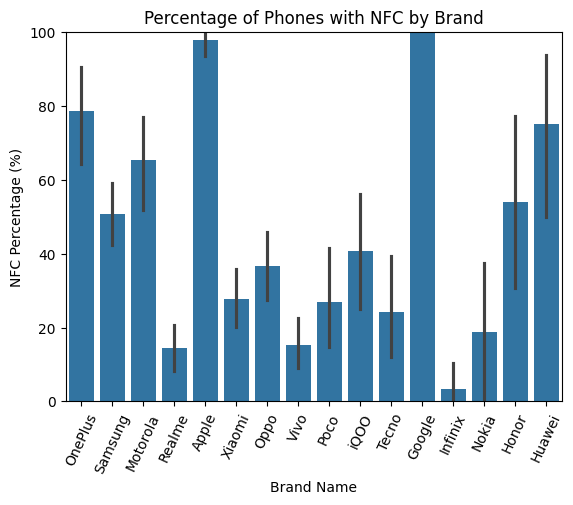

In [ ]:
sns.barplot(
    data=brand_df,
    x='brand_name',
    y='has_nfc',
    estimator=lambda x: x.mean() * 100,
)

plt.xticks(rotation=65)
plt.title('Percentage of Phones with NFC by Brand')
plt.xlabel("Brand Name")
plt.ylabel("NFC Percentage (%)")
plt.ylim(0, 100)
plt.show()

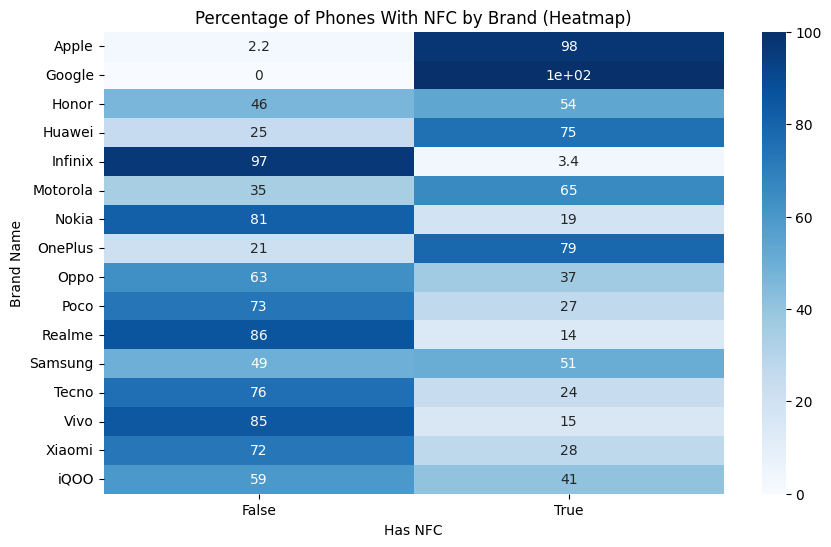

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(ct, annot=True, cmap="Blues")
plt.title("Percentage of Phones With NFC by Brand (Heatmap)")
plt.ylabel("Brand Name")
plt.xlabel("Has NFC")
plt.show()

#### brand_name vs has_ir_blaster
- Xiaomi leads significantly with 81.34% of their phones having IR Blaster, making it a signature feature of the brand
- Poco follows with 73.17%, which makes sense as Poco is a sub-brand of Xiaomi
- Chinese brands demonstrate higher prevalence of IR Blaster compared to others.

In [ ]:
ct = brand_df.groupby('brand_name')['has_ir_blaster'].apply(lambda x: x.mean()*100)
ct

,has_ir_blaster
brand_name,
Apple,0.000000
Google,0.000000
Honor,7.692308
Huawei,37.500000
Infinix,0.000000
Motorola,0.000000
Nokia,0.000000
OnePlus,0.000000
Oppo,0.000000


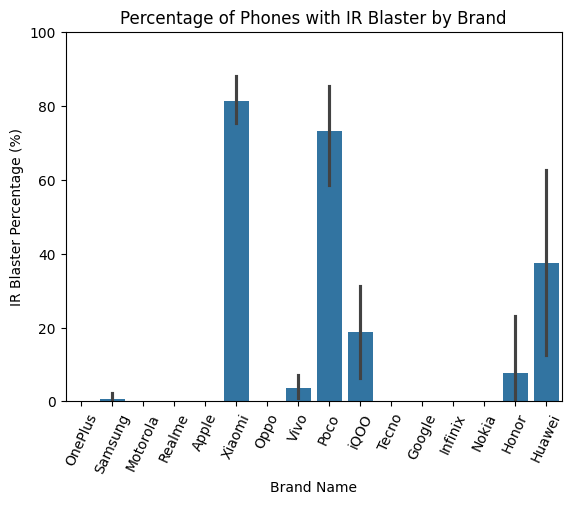

In [ ]:
sns.barplot(
    data=brand_df,
    x='brand_name',
    y='has_ir_blaster',
    estimator=lambda x: x.mean() * 100,
)

plt.xticks(rotation=65)
plt.title('Percentage of Phones with IR Blaster by Brand')
plt.xlabel("Brand Name")
plt.ylabel("IR Blaster Percentage (%)")
plt.ylim(0, 100)
plt.show()

In [ ]:
brand_df.head(3)

,brand_name,model,price,rating,sim_type,has_5g,has_nfc,has_ir_blaster,ram_capacity,storage_capacity,processor_core,processor_speed,battery_capacity,fast_charging,display_size,resolution,refresh_rate,no_of_rear_camera,no_of_front_camera,max_rear_camera_MP,max_front_camera_MP,card_supported,os,resolution_type,segment
0,OnePlus,OnePlus 11 5G,54999,89.0,Dual Sim,True,True,False,12.0,256.0,8.0,3.2,5000.0,100.0,6.70,1440 x 3216,120,3,1,50.0,16.0,0,Android v13,2K / QHD (1440p),Premium
1,OnePlus,OnePlus Nord CE 2 Lite 5G,19989,81.0,Dual Sim,True,False,False,6.0,128.0,8.0,2.2,5000.0,33.0,6.59,1080 x 2412,120,3,1,64.0,16.0,1,Android v12,Full HD (1080p),Premium
2,Samsung,Samsung Galaxy A14 5G,16499,75.0,Dual Sim,True,False,False,4.0,64.0,8.0,2.4,5000.0,15.0,6.60,1080 x 2408,90,3,1,50.0,13.0,1,Android v13,Full HD (1080p),Premium


### brand_name vs ram_capacity

- Most brands offer smartphones with RAM between 4 GB and 8 GB, showing standardization in mid-range capacity.

- Outliers exist for most brands with models reaching up to 12 GB or 16 GB RAM, indicating premium options.

- Brands like Google tend to have higher RAM on average, while Apple shows a narrower, usually lower RAM range which can be seen in the boxplot.

In [ ]:
brand_df.groupby('brand_name')['ram_capacity'].describe()

,count,mean,std,min,25%,50%,75%,max
brand_name,,,,,,,,
Apple,44.0,5.340909,1.363020,3.0,4.0,6.0,6.0,8.0
Google,14.0,8.000000,2.935198,4.0,6.0,8.0,11.0,12.0
Honor,13.0,7.692308,2.810238,4.0,6.0,8.0,8.0,12.0
Huawei,15.0,7.733333,1.830951,4.0,8.0,8.0,8.0,12.0
Infinix,29.0,5.862069,2.116671,2.0,4.0,6.0,8.0,8.0
Motorola,52.0,6.134615,2.114644,2.0,4.0,6.0,8.0,12.0
Nokia,14.0,5.500000,2.441626,2.0,4.0,6.0,6.0,12.0
OnePlus,42.0,8.238095,2.657796,4.0,8.0,8.0,8.0,16.0
Oppo,87.0,7.471264,2.856405,3.0,6.0,8.0,8.0,16.0


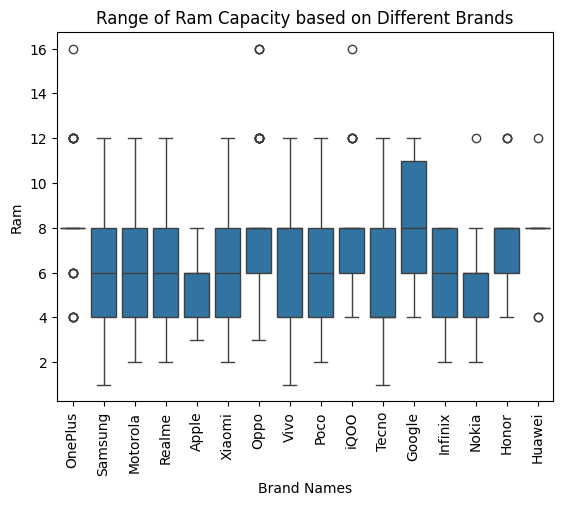

In [ ]:
sns.boxplot(data = brand_df,x = 'brand_name',y='ram_capacity')
plt.xticks(rotation = 'vertical')
plt.title("Range of Ram Capacity based on Different Brands")
plt.xlabel('Brand Names')
plt.ylabel('Ram')
plt.show()

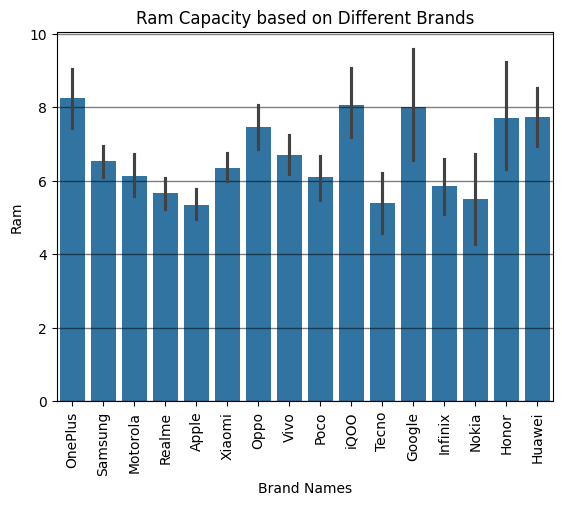

In [ ]:
sns.barplot(data = brand_df,x = 'brand_name', y='ram_capacity',estimator=np.mean)
plt.xticks(rotation = 'vertical')
plt.grid(linewidth=1, alpha=0.5,color = 'black',axis = 'y')
plt.title("Ram Capacity based on Different Brands")
plt.xlabel('Brand Names')
plt.ylabel('Ram')
plt.show()

#### brand_name vs storage_capacity

- Apple and Huawei phones have mean storage of around 256GB
- Other phones are of 64GB or 128GB

In [ ]:
brand_df.groupby('brand_name')['storage_capacity'].describe()

,count,mean,std,min,25%,50%,75%,max
brand_name,,,,,,,,
Apple,46.0,263.652174,271.963169,32.0,128.0,128.0,256.0,1024.0
Google,14.0,137.142857,55.324021,64.0,128.0,128.0,128.0,256.0
Honor,13.0,211.692308,146.373600,64.0,128.0,128.0,256.0,512.0
Huawei,16.0,248.000000,169.931751,64.0,128.0,192.0,320.0,512.0
Infinix,29.0,111.448276,59.634354,32.0,64.0,128.0,128.0,256.0
Motorola,52.0,116.307692,46.146203,32.0,64.0,128.0,128.0,256.0
Nokia,14.0,95.142857,64.919900,4.0,64.0,96.0,128.0,256.0
OnePlus,42.0,156.952381,82.666817,64.0,128.0,128.0,128.0,512.0
Oppo,87.0,154.482759,71.754728,32.0,128.0,128.0,256.0,256.0


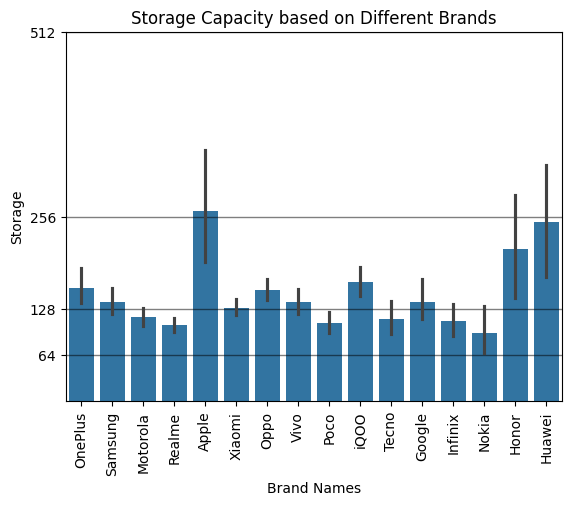

In [ ]:
sns.barplot(data = brand_df,x = 'brand_name', y='storage_capacity',estimator=np.mean)
plt.xticks(rotation = 'vertical')
plt.grid(linewidth=1, alpha=0.5,color = 'black',axis = 'y')
plt.title("Storage Capacity based on Different Brands")
plt.xlabel('Brand Names')
plt.ylabel('Storage')
plt.yticks([64, 128, 256, 512], ['64', '128', '256', '512'])
plt.show()

#### brand_df vs refresh_rate
- Most of the phones have refresh rate between 60Hz to 120Hz.
- Many phones have max refresh rate of 144Hz.
- IQOO has some outliers having 90Hz and 144Hz.

In [ ]:
brand_df.groupby('brand_name')['refresh_rate'].describe()

,count,mean,std,min,25%,50%,75%,max
brand_name,,,,,,,,
Apple,46.0,82.173913,29.281245,60.0,60.0,60.0,120.0,120.0
Google,14.0,90.000000,26.311741,60.0,60.0,90.0,120.0,120.0
Honor,13.0,96.923077,27.804261,60.0,60.0,120.0,120.0,120.0
Huawei,16.0,91.875000,25.617377,60.0,60.0,90.0,120.0,120.0
Infinix,29.0,81.724138,25.223142,60.0,60.0,60.0,90.0,120.0
Motorola,52.0,108.692308,31.557317,60.0,90.0,120.0,144.0,165.0
Nokia,16.0,85.500000,31.099839,60.0,60.0,75.0,97.5,144.0
OnePlus,42.0,107.714286,20.740306,60.0,90.0,120.0,120.0,144.0
Oppo,87.0,86.551724,25.235062,60.0,60.0,90.0,120.0,120.0


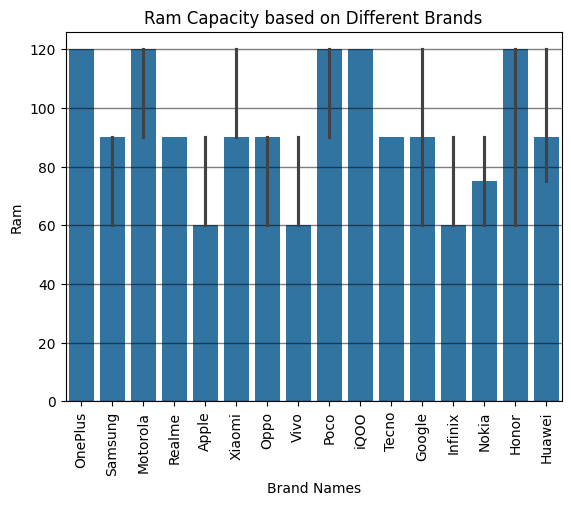

In [ ]:
sns.barplot(data = brand_df,x = 'brand_name', y='refresh_rate',estimator=np.median)
plt.xticks(rotation = 'vertical')
plt.grid(linewidth=1, alpha=0.5,color = 'black',axis = 'y')
plt.title("Ram Capacity based on Different Brands")
plt.xlabel('Brand Names')
plt.ylabel('Ram')
plt.show()

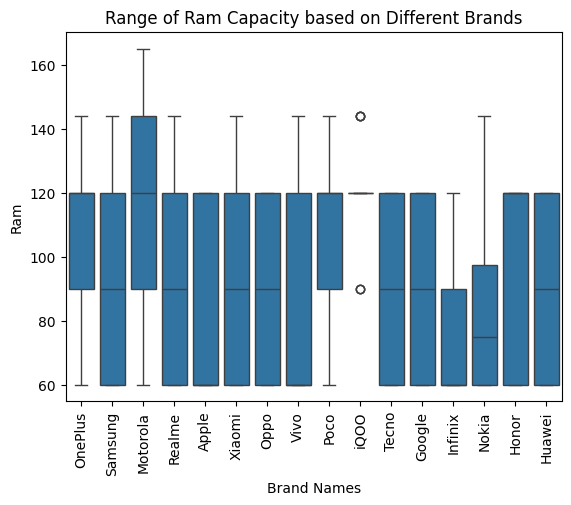

In [ ]:
sns.boxplot(data = brand_df,x = 'brand_name',y='refresh_rate')
plt.xticks(rotation = 'vertical')
plt.title("Range of Ram Capacity based on Different Brands")
plt.xlabel('Brand Names')
plt.ylabel('Ram')
plt.show()

#### rating vs ram_capacity

- Many devices have rating between ~8088 and RAM between ~6 GB and 10 GB.
- A smaller group of devices have very high RAM (1214 GB) and high ratings (~8590).
- Low RAM devices (24GB) typically have lower ratings (6075).


In [ ]:
df['rating'].corr(df['ram_capacity'])

np.float64(0.7590265592017955)

<Axes: xlabel='rating', ylabel='ram_capacity'>

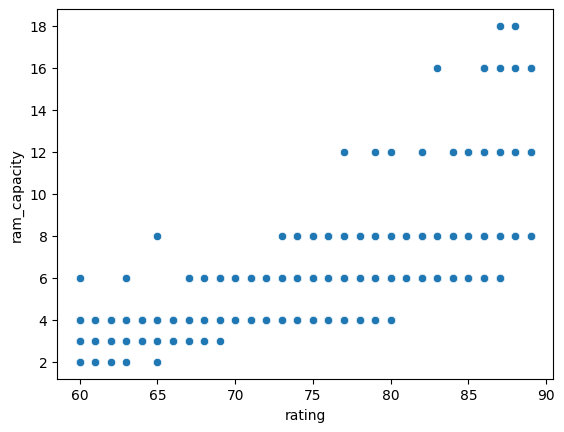

In [ ]:
sns.scatterplot(data = df,x='rating',y='ram_capacity')

<Axes: xlabel='rating', ylabel='ram_capacity'>

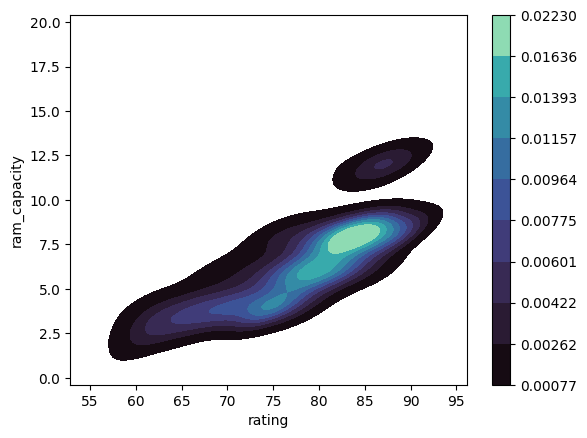

In [ ]:
sns.kdeplot(x=df['rating'], y=df['ram_capacity'], fill=True, cmap = 'mako', cbar = True)


#### rating vs storage_capacity

- Majority of smartphones have storage capacities clustered between 64 GB and 256 GB, regardless of rating.
- Higher-rated phones (ratings 80+) are available across all storage capacities, but extremely high storage models (512 GB, 1 TB) are rare.

In [ ]:
df['rating'].corr(df['storage_capacity'])

np.float64(0.4812500567367238)

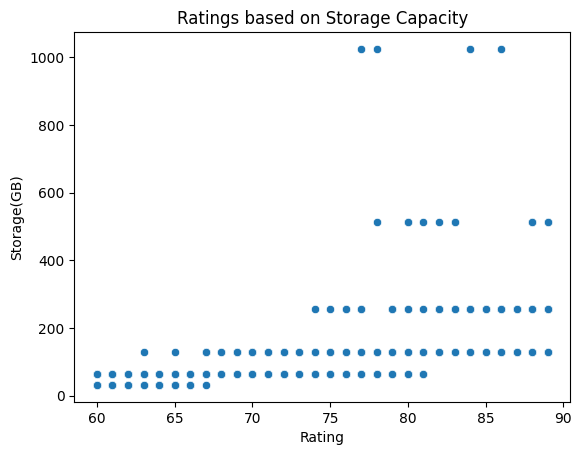

In [ ]:
sns.scatterplot(data = df,x='rating',y='storage_capacity')
plt.title("Ratings based on Storage Capacity")
plt.xlabel('Rating')
plt.ylabel('Storage(GB)')
plt.show()

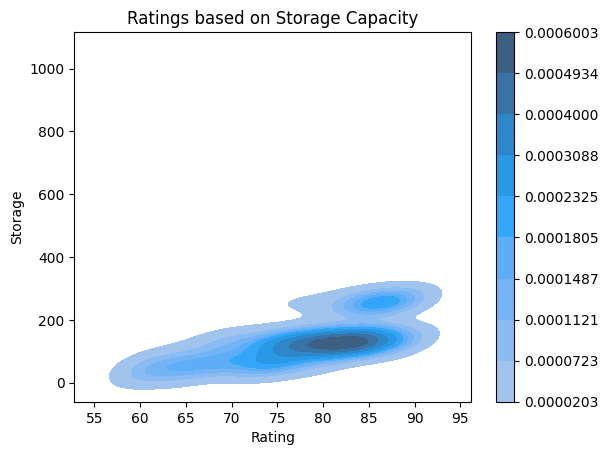

In [ ]:
sns.kdeplot(x=df['rating'], y=df['storage_capacity'], fill=True, cbar = True)
plt.title("Ratings based on Storage Capacity")
plt.xlabel('Rating')
plt.ylabel('Storage')
plt.show()

#### rating vs battery_capacity

- Most phones lie in the 35005500 mAh range.
-  Ratings cluster around 7585 for these mid-range battery devices.
-  Extreme batteries (10,00020,000 mAh) are rare outliers.
- KDE plot shows only a weak relationship between battery size and rating.
- Battery capacity does not significantly influence rating.

In [ ]:
df['rating'].corr(df['battery_capacity'])

np.float64(-0.015323116371538851)

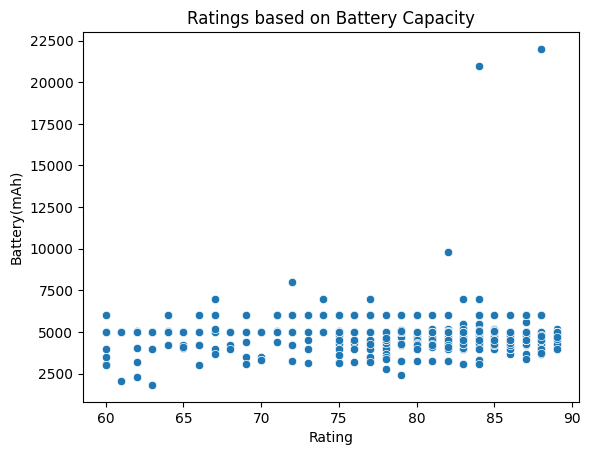

In [ ]:
sns.scatterplot(data = df,x='rating',y='battery_capacity')
plt.title("Ratings based on Battery Capacity")
plt.xlabel('Rating')
plt.ylabel('Battery(mAh)')
plt.show()

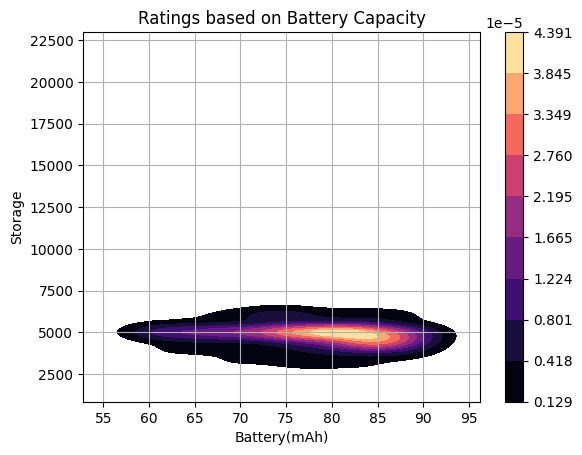

In [ ]:
sns.kdeplot(x=df['rating'], y=df['battery_capacity'],cmap = 'magma', fill=True, cbar = True)
plt.title("Ratings based on Battery Capacity")
plt.xlabel('Battery(mAh)')
plt.ylabel('Storage')
plt.grid()
plt.show()

#### rating vs processor_speed

- There is a positive relationship between processor speed and rating.

- Most devices with 2.02.8 GHz processors have mid-range ratings (7585).

- Higher-end phones with 3.0+ GHz processors tend to receive higher ratings (8590).

- Phones with lower processor speeds (1.52.0 GHz) tend to have lower ratings (6075)

In [ ]:
df['rating'].corr(df['processor_speed'])

np.float64(0.6209640870423367)

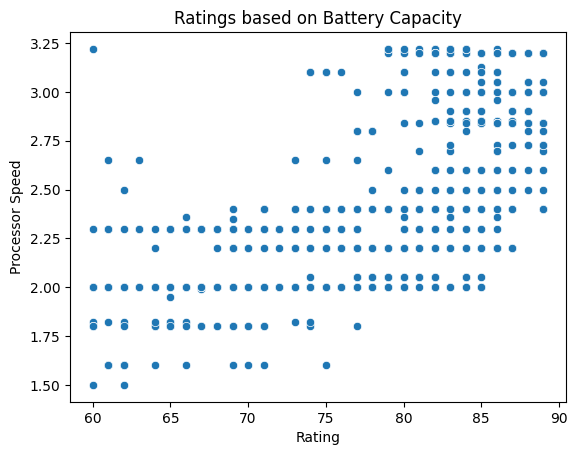

In [ ]:
sns.scatterplot(data = df,x='rating',y='processor_speed')
plt.title("Ratings based on Battery Capacity")
plt.xlabel('Rating')
plt.ylabel('Processor Speed')
plt.show()

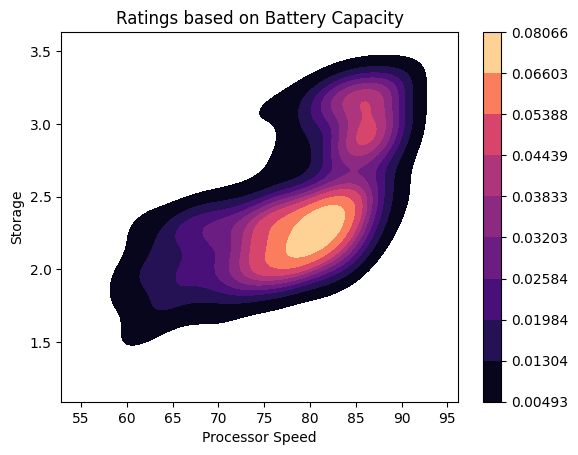

In [ ]:
sns.kdeplot(x=df['rating'], y=df['processor_speed'],cmap = 'magma', fill=True, cbar = True)
plt.title("Ratings based on Battery Capacity")
plt.xlabel('Processor Speed')
plt.ylabel('Storage')
plt.show()

#### rating vs max_rear_camera_MP

- Phones with low MP cameras (<20 MP) tend to have lower ratings (6075).

- Most mid-range phones have 4064 MP cameras, and they receive average to high ratings (7585).

- Premium phones with 108200 MP cameras appear only in the 8590 rating range.

- KDE shows a positive relationship between camera MP and rating,
but the relationship is moderate, not very strong.

In [ ]:
df['rating'].corr(df['max_rear_camera_MP'])

np.float64(0.562175995746704)

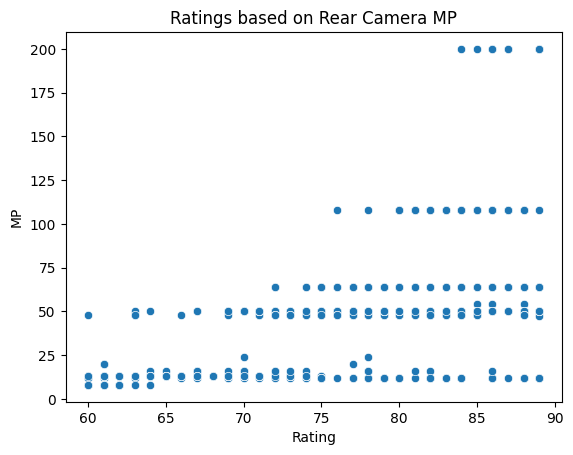

In [ ]:
sns.scatterplot(data = df,x='rating',y='max_rear_camera_MP')
plt.title("Ratings based on Rear Camera MP")
plt.xlabel('Rating')
plt.ylabel('MP')
plt.show()

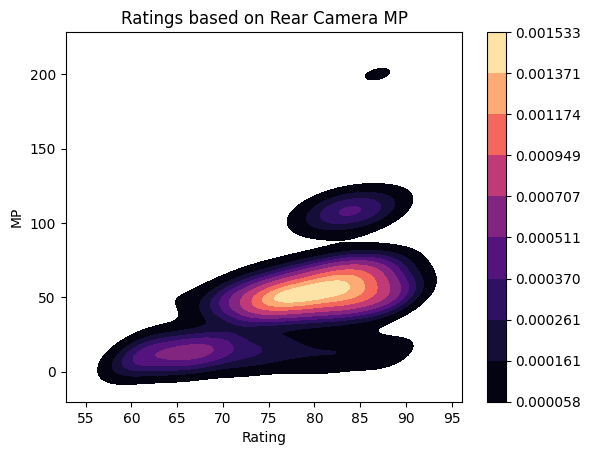

In [ ]:
sns.kdeplot(x=df['rating'], y=df['max_rear_camera_MP'],cmap = 'magma', fill=True, cbar = True)
plt.title("Ratings based on Rear Camera MP")
plt.xlabel('Rating')
plt.ylabel('MP')
plt.show()

#### rating vs max_front_camera_MP

- Phones with low MP cameras (<10 MP) tend to have lower ratings (6075).

- Most mid-range phones have 1220 MP cameras, and they receive average to high ratings (7587).

- Premium phones with 30-60 MP cameras mostly appear in the 8590 rating range.

- KDE shows a positive relationship between camera MP and rating,
but the relationship is moderate, not very strong.

In [ ]:
df['rating'].corr(df['max_front_camera_MP'])

np.float64(0.5775448170290886)

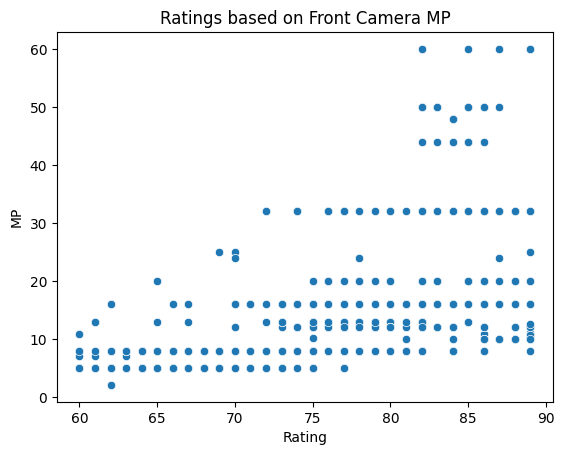

In [ ]:
sns.scatterplot(data = df,x='rating',y='max_front_camera_MP')
plt.title("Ratings based on Front Camera MP")
plt.xlabel('Rating')
plt.ylabel('MP')
plt.show()

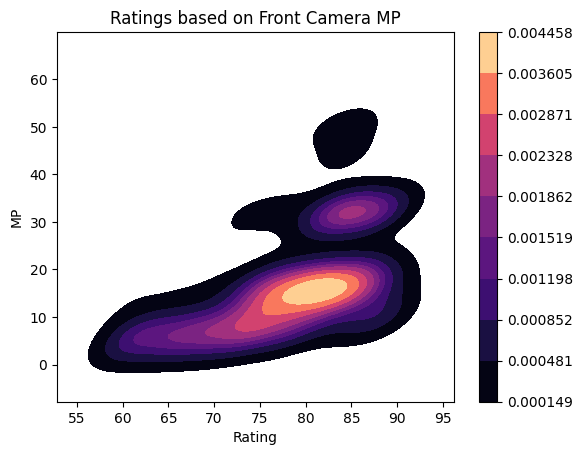

In [ ]:
sns.kdeplot(x=df['rating'], y=df['max_front_camera_MP'],cmap = 'magma', fill=True, cbar = True)
plt.title("Ratings based on Front Camera MP")
plt.xlabel('Rating')
plt.ylabel('MP')
plt.show()

#### rating vs has_5g

- Having 5g doesnt influence rating highly.
- phones with 5g have 83 median rating whereas phone without 5g have 74 median rating.

In [ ]:
df.groupby('has_5g').size().apply(lambda x: x*100/len(df)).rename("percentage")


,percentage
has_5g,
False,44.138634
True,55.861366


In [ ]:
df.groupby('has_5g')['rating'].describe()

,count,mean,std,min,25%,50%,75%,max
has_5g,,,,,,,,
False,389.0,73.308483,7.183705,60.0,68.0,74.0,79.0,89.0
True,489.0,82.186094,4.746885,60.0,79.0,83.0,86.0,89.0


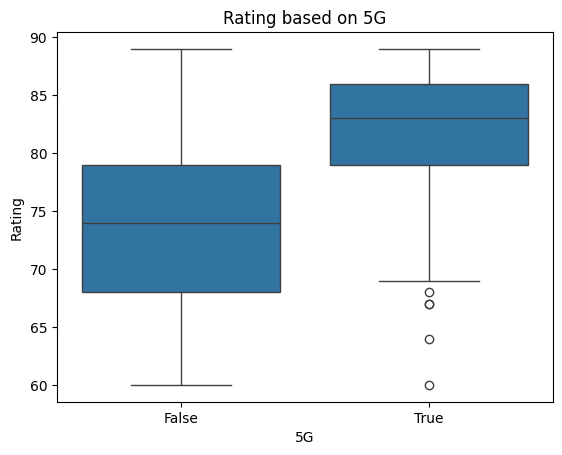

In [ ]:
sns.boxplot(data = df,x = 'has_5g', y = 'rating')
plt.title("Rating based on 5G")
plt.xlabel("5G")
plt.ylabel("Rating")
plt.show()

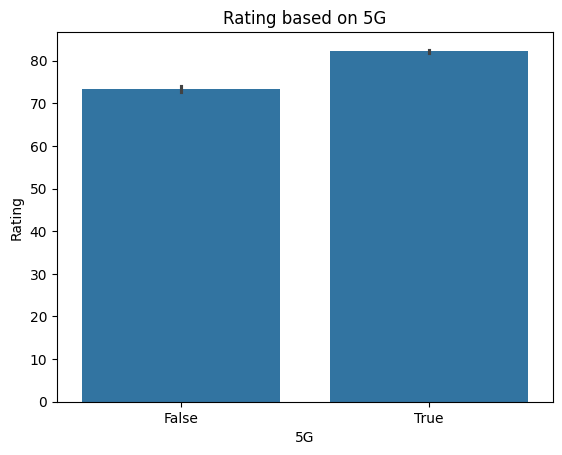

In [ ]:
sns.barplot(data =df,x = 'has_5g',y ='rating')
plt.title("Rating based on 5G")
plt.xlabel("5G")
plt.ylabel("Rating")
plt.show()

#### rating vs resolution_type

- Phones with 2K resolutions are dominating having 86 avg rating.
- Then there is Full HD having 80 avg rating.
- There are no phones Below HD.
- So we can say Resolution influence the rating.

In [ ]:
  df.groupby('resolution_type')['rating'].describe()

,count,mean,std,min,25%,50%,75%,max
resolution_type,,,,,,,,
2K / QHD (1440p),36.0,86.277778,4.151496,69.0,85.0,88.0,89.0,89.0
Below HD,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Full HD (1080p),642.0,80.965732,4.803997,60.0,78.0,82.0,85.0,89.0
HD (720p),200.0,68.100000,5.031559,60.0,64.0,68.0,72.0,79.0


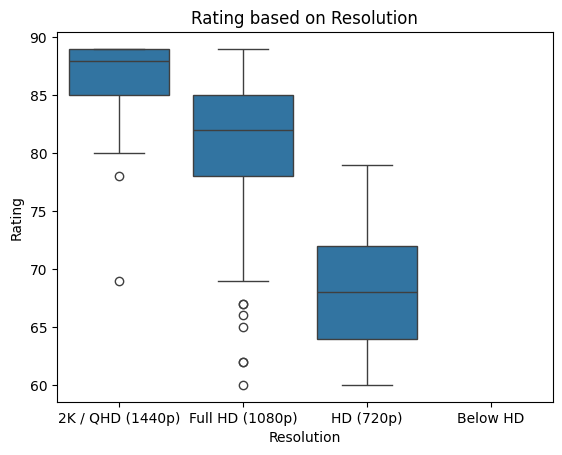

In [ ]:
sns.boxplot(data = df,x = 'resolution_type', y = 'rating')
plt.title("Rating based on Resolution")
plt.xlabel("Resolution")
plt.ylabel("Rating")
plt.show()

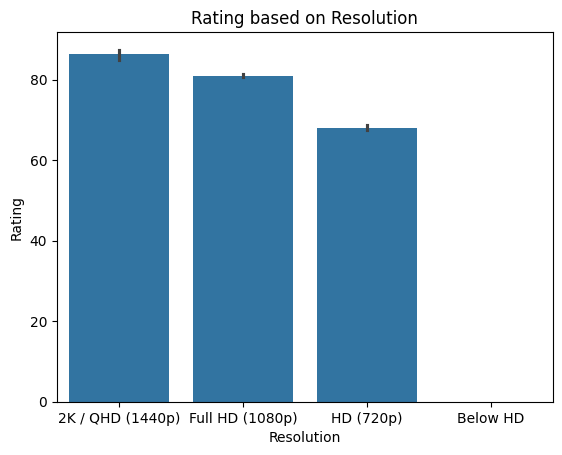

In [ ]:
sns.barplot(data =df,x = 'resolution_type',y ='rating')
plt.title("Rating based on Resolution")
plt.xlabel("Resolution")
plt.ylabel("Rating")
plt.show()

## **MultiVariate Analysis**


In [184]:
multi_df = df.copy()

In [185]:
multi_df[['has_5g','has_nfc','has_ir_blaster']] = df[['has_5g','has_nfc','has_ir_blaster']].astype(int)

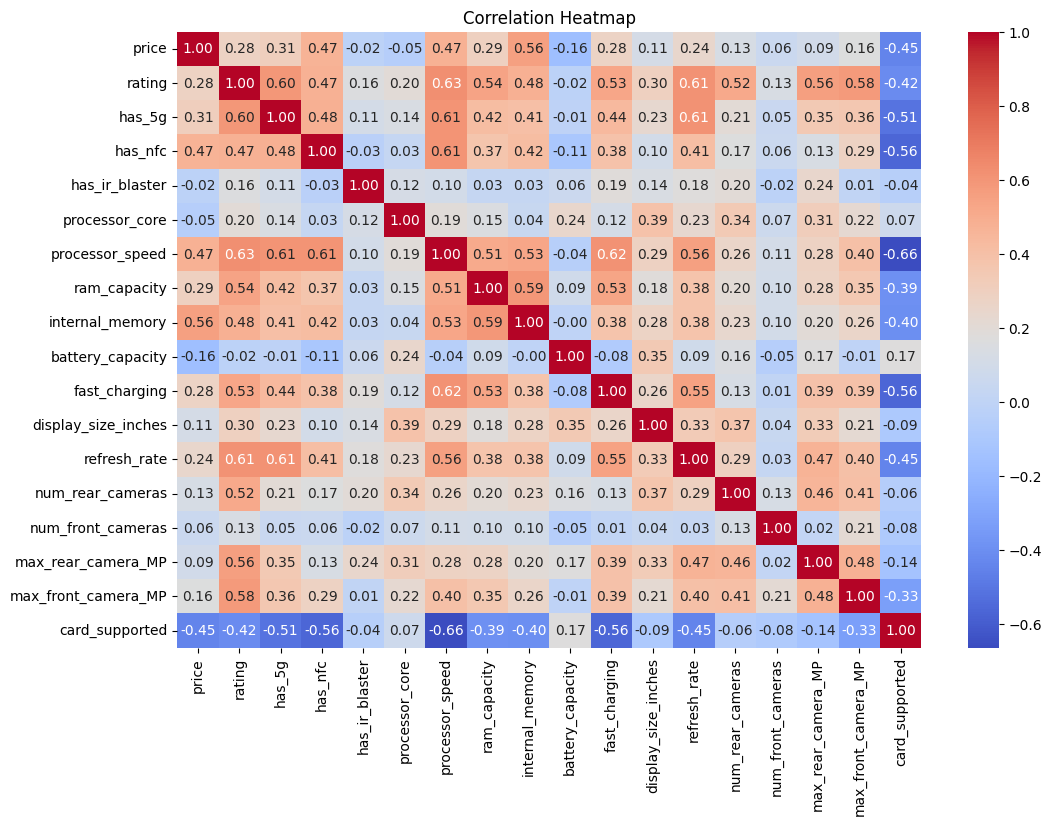

In [186]:
corr_matrix = multi_df.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

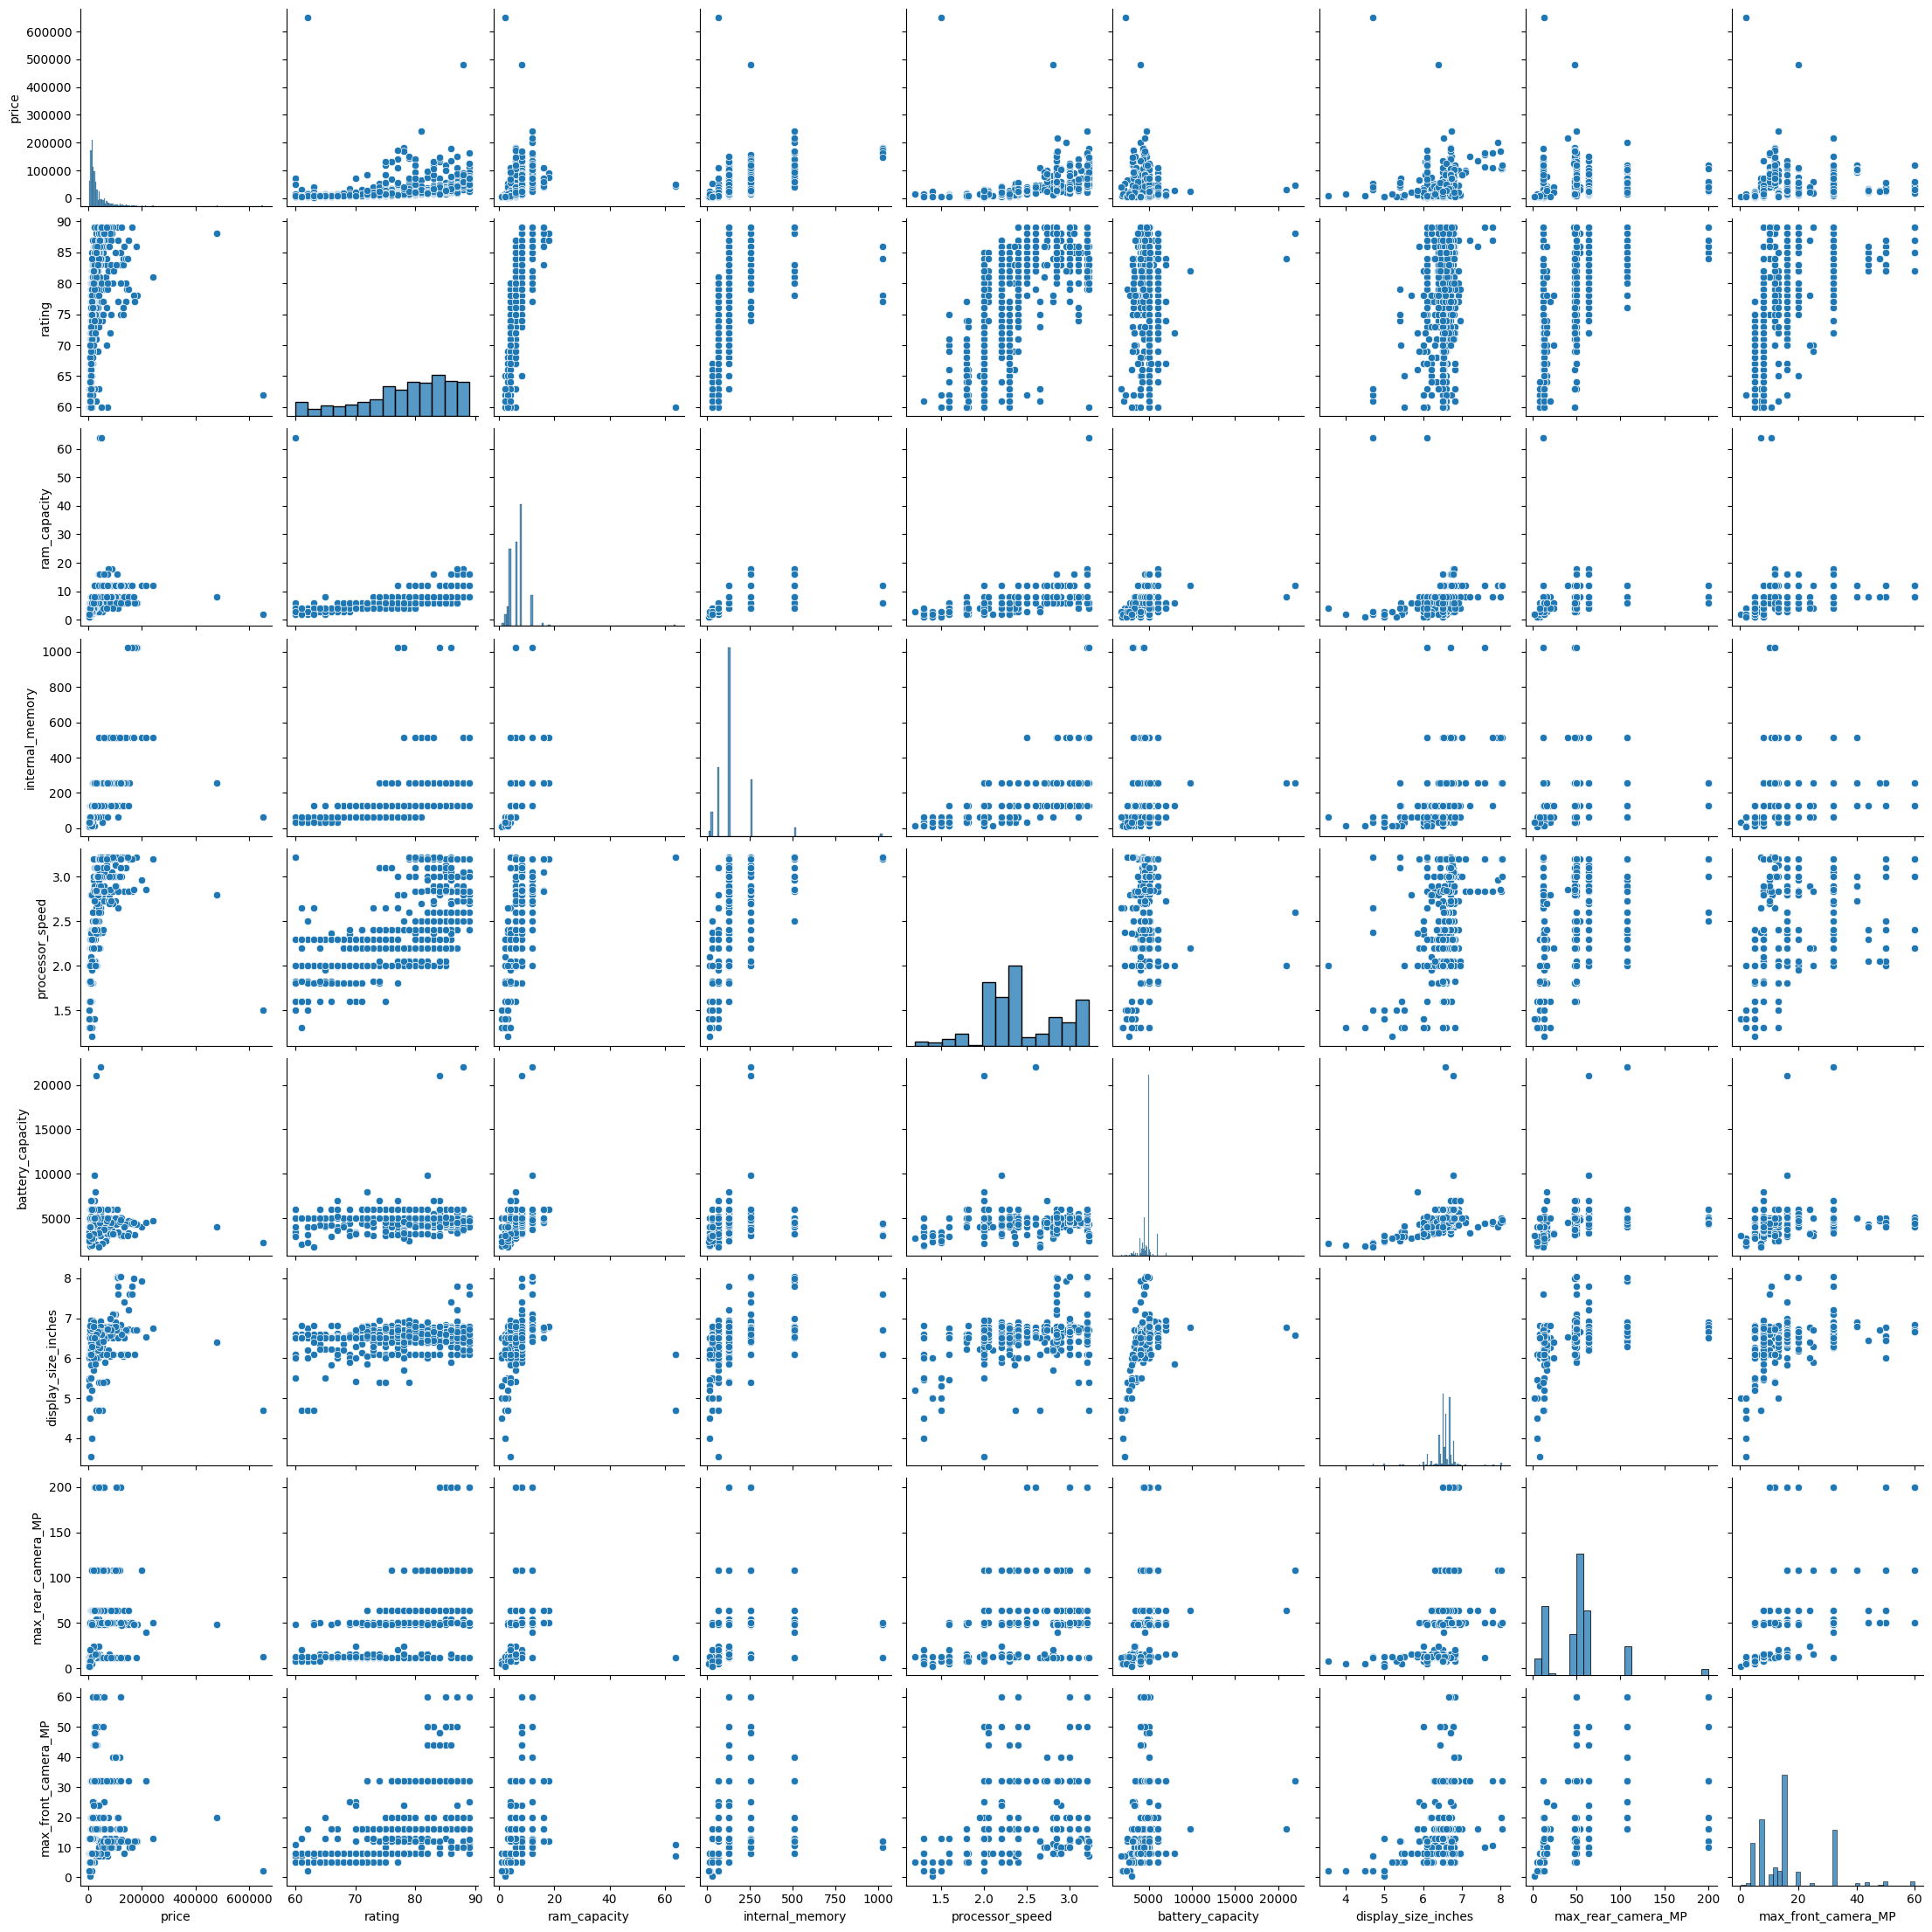

In [188]:
sns.pairplot(multi_df[['price', 'rating', 'ram_capacity', 'internal_memory',
 'processor_speed', 'battery_capacity', 'display_size_inches',
 'max_rear_camera_MP', 'max_front_camera_MP']])


In [189]:
brand_df.groupby('brand_name')['battery_capacity'].mean().sort_values(ascending=False)*100

NameError: name 'brand_df' is not defined

# **Questions Answered & Conclusion**


---


### **Q1: Which features drive smartphone prices the most?**

Price increases sharply with **storage (r = 0.56)** and **RAM (r = 0.56)**, followed by **processor speed (r = 0.42)**.

Battery, camera MP, and processor cores show **little to no influence** on price.

---

### **Q2: How does price vary across brands?**

Brands clearly segment into tiers:

- **Apple**  **95k**
- **Huawei**  **80k**  value-premium
- **Google 44k**  covers all segments
- **Samsung 38k**  covers all segments

---

### **Q3: Do 5G phones cost more?**

Yes , **5G phones average 42k vs 18k** for non-5G.

---

### **Q4: How do RAM and storage tiers map to price?**

- **24GB**  9,999
- **68GB**  24,000
- **12GB**  55,000
- **16GB**  49,997
- **64GB  14,000**, **128GB  27,000**, **256GB  60000**
- **2.0GHz chips  10k**, **3.0GHz  80k+**

---

### **Q5: Does refresh rate affect price?**

Weak overall correlation **(r = 0.25)**, but segmentation exists:

- 60 Hz  budget
- 90/120 Hz  mid-range
- 144 Hz  premium gaming

Refresh rate **separates tiers**, not price itself.

---

### **Q6: What is the price sweet spot of the market?**

**24,99935,000** is the sweet spot:

- 68GB RAM, 128GB storage
- 120Hz displays
- 5064MP cameras
- Ratings: **8185**
- Covers **46.5%** of the entire market

Delivers **90% of flagship specs at 40% of flagship price**.



---



### **Q7: Which features influence ratings most?**

Strongest drivers of rating:

- **RAM (r = 0.76)**
- **Processor speed (r = 0.62)**
- **Front/Rear camera MP ( 0.56)**

---

### **Q8: Do expensive phones get higher ratings?**

**No direct relationship.**

15k and 100k phones both achieve **85+ ratings**.

Users reward **smooth experience**, not price.

---

### **Q9: Do 5G phones get better ratings?**

Yes  **5G phones score +9 points higher** on average

(82.2 vs 73.3).

This is due to **newer releases + bundled specs**, not 5G itself.

---

### **Q10: Do camera megapixels improve ratings?**

- Moderately

---

### **Q11: Which brands have the highest ratings?**

- **OnePlus = 82.24**
- **iQOO = 82.2**
- Premium mid and budget segments almost have same ratings.
- **Apple = 76.8** (older models lower the average)



---

### **Q12: Most common feature combination in the market?**

- 68GB RAM
- 128GB storage
- 5000mAh battery
- 6.56.7" display
- Price: 15k40k

This is the **modern mid-range standard**.

---

### **Q13: How are performance features correlated?**

- RAM  Processor speed (**r = 0.68**)
- RAM  Storage (**r = 0.65**)

---

### **Q14: Battery vs fast charging?**

Weak correlation (r = -0.08).

Charging speed !== bigger battery.

---

### **Q15: Do more cameras mean higher price or rating?**

No  camera count has **very weak influence.**

Quality > quantity.

---

### **Q16: Which brands lead in specific features (5G, fast charging, etc.)?**

- **iQOO  93.8% 5G phones**
- **OnePlus  fastest charging**
- **Xiaomi/POCO  IR Blaster included (73.81%)**

---